# Notebook: Qualitative Evaluation (Expert Analysis) -- Experiment 2

In this notebook, the qualitative evaluation of Experiment 2 is conducted for the question-generation behind RQ2 and RQ3.

The notebook uses one evaluation setup with exactly 3 experts. \
Question and answer quality criteria are rated on a 1-5 Likert scale and analyzed separately and as combined total scores.  
The Bloom level itself is rated on a 1-6 scale by experts, and Bloom alignment is derived as alignment points (1/3/5).

Question and answer ratings are analyzed separately and as combined total scores for the non-Bloom Likert criteria. Bloom alignment is analyzed separately using its own 1-6 scale.

## Initial Setup

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
from statsmodels.stats.inter_rater import fleiss_kappa

warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.notebook_repr_html', True)

LIKERT_MIN = 1
LIKERT_MAX = 5
LIKERT_RANGE = (LIKERT_MIN, LIKERT_MAX)
BLOOM_MIN = 1
BLOOM_MAX = 6
BLOOM_RANGE = (BLOOM_MIN, BLOOM_MAX)
ALIGNMENT_POINT_RANGE = (1, 5)
EXPERT_IDS = [1, 2, 3]
ANALYSIS_SUFFIX = 'experts'

EXP2_QUESTION_COLS = [
    'q_clarity',
    'q_challenging',
    'q_value',
    'q_language',
]
EXP2_ANSWER_COLS = [
    'a_clarity',
    'a_language',
]
EXP2_BLOOM_COLS = [
    'q_bloom_rating',
    'a_bloom_rating',
]
EXP2_ALIGNMENT_COLS = [
    'q_bloom_alignment',
    'a_bloom_alignment',
    'bloom_alignment_total',
]
EXP2_NUMERIC_COLS = EXP2_QUESTION_COLS + EXP2_ANSWER_COLS + EXP2_ALIGNMENT_COLS
EXP2_SCORE_COLS = ['question_total_score', 'answer_total_score', 'total_score']

SCORE_RANGES = {
    'question_total_score': (len(EXP2_QUESTION_COLS) * LIKERT_MIN, len(EXP2_QUESTION_COLS) * LIKERT_MAX),
    'answer_total_score': (len(EXP2_ANSWER_COLS) * LIKERT_MIN, len(EXP2_ANSWER_COLS) * LIKERT_MAX),
    'total_score': ((len(EXP2_QUESTION_COLS) + len(EXP2_ANSWER_COLS)) * LIKERT_MIN, (len(EXP2_QUESTION_COLS) + len(EXP2_ANSWER_COLS)) * LIKERT_MAX),
    'q_bloom_alignment': ALIGNMENT_POINT_RANGE,
    'a_bloom_alignment': ALIGNMENT_POINT_RANGE,
    'bloom_alignment_total': (2, 10),
    'question_total_with_alignment': (5, 25),
    'answer_total_with_alignment': (3, 15),
    'total_with_alignment': (8, 40),
}

DISPLAY_LABELS = {
    'q_clarity': 'qClarity',
    'q_challenging': 'qChallenging',
    'q_value': 'qValue',
    'q_language': 'qLanguage',
    'q_bloom_rating': 'qBloomRating',
    'a_clarity': 'aClarity',
    'a_language': 'aLanguage',
    'a_bloom_rating': 'aBloomRating',
    'question_total_score': 'qTotal',
    'answer_total_score': 'aTotal',
    'total_score': 'total',
    'q_bloom_alignment': 'qBloomAlignment',
    'a_bloom_alignment': 'aBloomAlignment',
    'bloom_alignment_total': 'bloomAlignmentTotal',
    'question_total_with_alignment': 'qTotalWithAlignment',
    'answer_total_with_alignment': 'aTotalWithAlignment',
    'total_with_alignment': 'totalWithAlignment',
}

BASE_PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
qualitative_base_path = os.path.join(BASE_PROJECT_PATH, '20_experiments/60_analyses/csv/qualitative/exp2')
sampled_hints_path = os.path.join(BASE_PROJECT_PATH, '20_experiments/60_analyses/csv/sampled/exp2_sampled.csv')
output_base_path = os.path.join(BASE_PROJECT_PATH, '40_evaluation/exp2/qualitative')
output_tables_path = os.path.join(output_base_path, 'tables')
output_plots_path = os.path.join(output_base_path, 'plots')

for path in [output_tables_path, output_plots_path]:
    os.makedirs(path, exist_ok=True)

LABEL_MAPPING = {
    'anthropic': 'Anthropic',
    'openai': 'OpenAI',
    'deepseek': 'DeepSeek',
    'xai': 'xAI',
    'google': 'Google',
    'mcq': 'MCQ',
    'open_ended': 'Open-Ended',
}

tables = {}
plots = {}

print('Setup completed successfully')
print(f'Output tables: {output_tables_path}')
print(f'Output plots: {output_plots_path}')
print(f'Experts configured: {EXPERT_IDS}')
print('Likert scale: 1-5 | Bloom source scale: 1-6 | Alignment points: 1/3/5')

Setup completed successfully
Output tables: /home/malde/git/question-generation/40_evaluation/exp2/qualitative/tables
Output plots: /home/malde/git/question-generation/40_evaluation/exp2/qualitative/plots
Experts configured: [1, 2, 3]
Likert scale: 1-5 | Bloom source scale: 1-6 | Alignment points: 1/3/5


In [2]:
# Utility Functions

def normalize_sample_id(series):
    return series.astype(str).str.extract(r'(\d+)')[0].str.zfill(3)


def create_seaborn_boxplot(data, x, y, ax, title, ylabel, xlabel, scale_range=None):
    plot_df = data[[x, y]].dropna().copy()
    if plot_df.empty:
        ax.set_title(f'{title} - No data', fontsize=12, fontweight='bold')
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return

    colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3']
    order = sorted(plot_df[x].dropna().unique(), key=lambda value: str(value))
    palette = colors[:len(order)]

    sns.boxplot(
        data=plot_df,
        x=x,
        y=y,
        order=order,
        ax=ax,
        palette=palette,
        medianprops={'color': 'black', 'linewidth': 2.5, 'linestyle': ':'},
    )

    for i, value in enumerate(order):
        mean_val = plot_df.loc[plot_df[x] == value, y].mean()
        ax.scatter(i, mean_val, color='red', marker='D', s=50, zorder=3, edgecolor='darkred', linewidth=1)

    ax.set_xticklabels([LABEL_MAPPING.get(str(label), str(label)) for label in order], rotation=0)

    if scale_range is not None:
        padding = 0.1 if scale_range[1] <= 6 else 0.5
        ax.set_ylim(scale_range[0] - padding, scale_range[1] + padding)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, labelpad=15)
    ax.set_xlabel(xlabel, fontsize=11, labelpad=10)
    ax.grid(True, alpha=0.3)


def create_heatmap(data, index_col, column_col, value_col, ax, title, cbar_label, scale_range=None):
    heatmap_mean = data.groupby([index_col, column_col])[value_col].mean().unstack()
    heatmap_std = data.groupby([index_col, column_col])[value_col].std().unstack()

    annot_matrix = heatmap_mean.copy().astype(object)
    for i in range(len(heatmap_mean.index)):
        for j in range(len(heatmap_mean.columns)):
            mean_val = heatmap_mean.iloc[i, j]
            std_val = heatmap_std.iloc[i, j]
            if pd.notna(mean_val) and pd.notna(std_val):
                annot_matrix.iloc[i, j] = f'{mean_val:.2f}\n({std_val:.2f})'
            elif pd.notna(mean_val):
                annot_matrix.iloc[i, j] = f'{mean_val:.2f}'
            else:
                annot_matrix.iloc[i, j] = ''

    yticklabels = [LABEL_MAPPING.get(str(label), str(label).title()) for label in heatmap_mean.index]
    xticklabels = [LABEL_MAPPING.get(str(label), str(label).title()) for label in heatmap_mean.columns]

    heatmap_kwargs = {
        'annot': annot_matrix,
        'fmt': '',
        'cmap': 'RdYlBu_r',
        'square': True,
        'linewidths': 0.5,
        'cbar_kws': {'shrink': 0.8, 'label': cbar_label},
        'annot_kws': {'size': 10, 'weight': 'bold'},
        'xticklabels': xticklabels,
        'yticklabels': yticklabels,
        'ax': ax,
    }

    if scale_range is not None:
        heatmap_kwargs['vmin'] = scale_range[0]
        heatmap_kwargs['vmax'] = scale_range[1]
        heatmap_kwargs['center'] = (scale_range[0] + scale_range[1]) / 2
    elif not heatmap_mean.empty:
        heatmap_kwargs['center'] = heatmap_mean.mean().mean()

    sns.heatmap(heatmap_mean, **heatmap_kwargs)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel(LABEL_MAPPING.get(column_col, column_col.replace('_', ' ').title()), fontsize=12, fontweight='bold')
    ax.set_ylabel(LABEL_MAPPING.get(index_col, index_col.replace('_', ' ').title()), fontsize=12, fontweight='bold')


print('Utility functions loaded successfully')

Utility functions loaded successfully


In [3]:
def enrich_exp2_metadata(df):
    if not os.path.exists(sampled_hints_path):
        raise FileNotFoundError(f'Sampled file not found at {sampled_hints_path}')

    sampled_df = pd.read_csv(sampled_hints_path).copy()
    sampled_df['sample_id'] = [f'{i + 1:03d}' for i in range(len(sampled_df))]

    df = df.copy()
    df['sample_id'] = normalize_sample_id(df['sample_id'])

    exp2_df = pd.merge(
        df,
        sampled_df[['sample_id', 'llm', 'question_type', 'bloom_idx']],
        on='sample_id',
        how='left',
        suffixes=('', '_meta'),
    )

    if 'question_type_meta' in exp2_df.columns:
        if 'question_type' in exp2_df.columns:
            exp2_df['question_type'] = exp2_df['question_type'].combine_first(exp2_df['question_type_meta'])
        else:
            exp2_df['question_type'] = exp2_df['question_type_meta']
        exp2_df = exp2_df.drop(columns=['question_type_meta'])

    if 'question_type' in exp2_df.columns:
        valid_types = ['mcq', 'open_ended']
        exp2_df['question_type'] = exp2_df['question_type'].where(exp2_df['question_type'].isin(valid_types), pd.NA)

    exp2_df['bloom_idx'] = pd.to_numeric(exp2_df.get('bloom_idx'), errors='coerce')

    return exp2_df


def load_all_experts_data():
    experts_data = {}
    all_expert_dfs = []

    for expert_num in EXPERT_IDS:
        expert_key = f'expert_{expert_num}'
        expert_file = os.path.join(qualitative_base_path, f'exp2_eval_e{expert_num}.csv')

        if not os.path.exists(expert_file):
            print(f'Skip {expert_key}: file missing ({expert_file})')
            continue

        expert_df = pd.read_csv(expert_file)

        if expert_df.empty:
            print(f'Skip {expert_key}: empty CSV')
            continue

        first_row = expert_df.iloc[0]
        empty_count = first_row.apply(
            lambda v: pd.isna(v) or (isinstance(v, str) and v.strip() == '')
        ).sum()

        if empty_count >= 4:
            print(f'Skip {expert_key}: first data row has {empty_count} empty fields (>=4)')
            continue

        expert_df = enrich_exp2_metadata(expert_df)
        expert_df['expert'] = expert_key
        experts_data[expert_key] = expert_df.copy()
        all_expert_dfs.append(expert_df)

    if not all_expert_dfs:
        raise ValueError('No usable expert CSV found.')

    exp2_df = pd.concat(all_expert_dfs, ignore_index=True)
    return exp2_df, experts_data

In [4]:
def clean_numeric_data(df, numeric_cols, min_value=1, max_value=5, use_semicolon_max=False):
    invalid_values = [
        '??', '???', '?', '????', '', ' ', 'nan', 'NaN', 'NULL', 'null',
        'None', 'NONE', 'n/a', 'N/A', '#N/A', '#NULL!',
        'undefined', 'UNDEFINED', '-', '--', '---', '-99',
    ]

    def _parse_value(value):
        if pd.isna(value):
            return np.nan

        value_str = str(value).strip()
        if value_str in invalid_values:
            return np.nan

        if use_semicolon_max and ';' in value_str:
            parts = [part.strip() for part in value_str.split(';') if part.strip() != '']
            numeric_parts = pd.to_numeric(pd.Series(parts), errors='coerce').dropna()
            if numeric_parts.empty:
                return np.nan
            return float(numeric_parts.max())

        return pd.to_numeric(value_str, errors='coerce')

    df = df.copy()
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].apply(_parse_value)
            df.loc[(df[col] < min_value) | (df[col] > max_value), col] = np.nan
    return df


def bloom_alignment_points(actual_rating, target_rating):
    if pd.isna(actual_rating) or pd.isna(target_rating):
        return np.nan

    actual = int(actual_rating)
    target = int(target_rating)
    diff = abs(actual - target)

    if diff == 0:
        return 5
    if diff == 1:
        return 3
    return 1


def calculate_exp2_scores(df):
    df = df.copy()
    df['question_total_score'] = df[EXP2_QUESTION_COLS].sum(axis=1, min_count=len(EXP2_QUESTION_COLS))
    df['answer_total_score'] = df[EXP2_ANSWER_COLS].sum(axis=1, min_count=len(EXP2_ANSWER_COLS))
    df['total_score'] = df[EXP2_QUESTION_COLS + EXP2_ANSWER_COLS].sum(
        axis=1, min_count=len(EXP2_QUESTION_COLS + EXP2_ANSWER_COLS)
    )

    df['q_bloom_alignment'] = df.apply(
        lambda row: bloom_alignment_points(row.get('q_bloom_rating'), row.get('bloom_idx')),
        axis=1,
    )
    df['a_bloom_alignment'] = df.apply(
        lambda row: bloom_alignment_points(row.get('a_bloom_rating'), row.get('q_bloom_rating')),
        axis=1,
    )
    df['bloom_alignment_total'] = df[['q_bloom_alignment', 'a_bloom_alignment']].sum(
        axis=1, min_count=2
    )

    df['question_total_with_alignment'] = df[['question_total_score', 'q_bloom_alignment']].sum(
        axis=1, min_count=2
    )
    df['answer_total_with_alignment'] = df[['answer_total_score', 'a_bloom_alignment']].sum(
        axis=1, min_count=2
    )
    df['total_with_alignment'] = df[['total_score', 'bloom_alignment_total']].sum(
        axis=1, min_count=2
    )
    return df


def calculate_fleiss_kappa_for_columns(expert_dfs_dict, criteria_cols, min_value, max_value):
    results = []
    expert_keys = sorted(expert_dfs_dict.keys())
    if len(expert_keys) < 2:
        print('Need at least 2 experts for agreement analysis')
        return pd.DataFrame()

    allowed = set(range(min_value, max_value + 1))

    def _unique_valid_rating(series: pd.Series):
        s = pd.to_numeric(series, errors='coerce').dropna()
        s = s[s.isin(allowed)]
        uniques = pd.unique(s)
        if len(uniques) == 1:
            return float(uniques[0])
        return np.nan

    collapsed = {}
    base_common_ids = None

    for expert_key in expert_keys:
        df = expert_dfs_dict[expert_key].copy()
        if 'sample_id' not in df.columns:
            print(f'Skip {expert_key}: missing sample_id column')
            continue

        df['sample_id'] = normalize_sample_id(df['sample_id'])
        keep_cols = ['sample_id'] + [c for c in criteria_cols if c in df.columns]
        df = df[keep_cols].copy()

        for criterion in keep_cols:
            if criterion != 'sample_id':
                df[criterion] = pd.to_numeric(df[criterion], errors='coerce')

        collapsed_df = df.groupby('sample_id', dropna=True).agg({
            c: _unique_valid_rating for c in keep_cols if c != 'sample_id'
        })
        collapsed[expert_key] = collapsed_df

        ids = set(collapsed_df.index.dropna().astype(str))
        base_common_ids = ids if base_common_ids is None else (base_common_ids & ids)

    if not collapsed or not base_common_ids:
        print('No common sample_ids found across experts')
        return pd.DataFrame()

    base_common_ids = sorted(base_common_ids)
    print(f'Analyzing {len(collapsed)} experts with {len(base_common_ids)} common samples')

    for criterion in criteria_cols:
        if any(criterion not in collapsed[k].columns for k in collapsed.keys()):
            continue

        valid_ids = set(base_common_ids)
        for expert_key in collapsed.keys():
            s = collapsed[expert_key][criterion]
            valid_ids &= set(s[s.notna()].index.astype(str))

        valid_ids = sorted(valid_ids)
        if len(valid_ids) < 2:
            continue

        ratings = []
        for sample_id in valid_ids:
            item = []
            ok = True
            for expert_key in collapsed.keys():
                val = collapsed[expert_key].loc[sample_id, criterion]
                if pd.isna(val) or (val not in allowed):
                    ok = False
                    break
                item.append(int(val))
            if ok:
                ratings.append(item)

        if len(ratings) < 2:
            continue

        ratings_array = np.asarray(ratings, dtype=int)
        fleiss_table = np.zeros((len(ratings), max_value - min_value + 1), dtype=int)
        for i, item_ratings in enumerate(ratings):
            for r in item_ratings:
                fleiss_table[i, r - min_value] += 1

        kappa = fleiss_kappa(fleiss_table)
        level = (
            'Poor' if kappa < 0 else
            'Slight' if kappa < 0.2 else
            'Fair' if kappa < 0.4 else
            'Moderate' if kappa < 0.6 else
            'Substantial' if kappa < 0.8 else
            'Almost Perfect'
        )

        if criterion in EXP2_QUESTION_COLS or criterion == 'q_bloom_rating':
            rating_domain = 'Question'
        elif criterion in EXP2_ANSWER_COLS or criterion == 'a_bloom_rating':
            rating_domain = 'Answer'
        else:
            rating_domain = 'Other'

        results.append({
            'Criterion': criterion,
            'Display_Label': DISPLAY_LABELS.get(criterion, criterion),
            'Fleiss_Kappa': round(float(kappa), 3),
            'Agreement_Level': level,
            'N_Items': int(len(ratings)),
            'N_Raters': int(len(collapsed)),
            'Mean_Rating': round(float(ratings_array.mean()), 2),
            'Std_Rating': round(float(ratings_array.std()), 2),
            'Scale': f'{min_value}-{max_value}',
            'Rating_Domain': rating_domain,
        })

    return pd.DataFrame(results)


print('Scoring and agreement helpers loaded successfully')

Scoring and agreement helpers loaded successfully


## Data Loading and Configuration

In [5]:
print(f'Loading unified expert data (Experts {EXPERT_IDS[0]}-{EXPERT_IDS[-1]})')
exp2_df, experts_data = load_all_experts_data()
agreement_available = len(experts_data) >= 2
analysis_suffix = ANALYSIS_SUFFIX

exp2_df = clean_numeric_data(exp2_df, EXP2_QUESTION_COLS + EXP2_ANSWER_COLS, LIKERT_MIN, LIKERT_MAX)
exp2_df = clean_numeric_data(exp2_df, EXP2_BLOOM_COLS, BLOOM_MIN, BLOOM_MAX, use_semicolon_max=True)
exp2_df = calculate_exp2_scores(exp2_df)
criteria = EXP2_NUMERIC_COLS + EXP2_SCORE_COLS

filled_non_bloom = exp2_df[EXP2_QUESTION_COLS + EXP2_ANSWER_COLS].notna().sum().sum()
total_non_bloom = len(exp2_df) * len(EXP2_QUESTION_COLS + EXP2_ANSWER_COLS)
completion_pct = (100 * filled_non_bloom / total_non_bloom) if total_non_bloom else 0

print('\nData loaded successfully!')
print(f'Experiment 2: {len(exp2_df)} rows, {completion_pct:.1f}% non-Bloom rating completion')
print(f'Experts loaded: {list(experts_data.keys())}')

if 'llm' in exp2_df.columns:
    print('\nDistribution:')
    print(f"  LLMs: {list(exp2_df['llm'].dropna().unique())}")
if 'question_type' in exp2_df.columns:
    print(f"  Question Types: {list(exp2_df['question_type'].dropna().unique())}")
if 'bloom_idx' in exp2_df.columns:
    print(f"  Bloom Levels: {sorted(exp2_df['bloom_idx'].dropna().unique())}")

Loading unified expert data (Experts 1-3)

Data loaded successfully!
Experiment 2: 72 rows, 100.0% non-Bloom rating completion
Experts loaded: ['expert_1', 'expert_2', 'expert_3']

Distribution:
  LLMs: ['anthropic', 'deepseek', 'openai', 'xai']
  Question Types: ['mcq', 'open_ended']
  Bloom Levels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


# Experiment 2: Learning Objective and Bloom Alignment Analysis

Analysis of LLM question generation quality with explicit Bloom-level alignment criteria.

In [6]:
print('EXPERIMENT 2 - DESCRIPTIVE STATISTICS')
print('=' * 60)

criteria = EXP2_NUMERIC_COLS + EXP2_SCORE_COLS
exp2_stats = exp2_df[criteria].describe().round(2)
tables[f'exp2_overall_stats_{analysis_suffix}'] = exp2_stats
print('\nOverall Statistics:')
display(exp2_stats)

exp2_llm_stats = exp2_df.groupby('llm')[criteria].agg(['mean', 'std', 'median', 'count']).round(2)
tables[f'exp2_llm_stats_{analysis_suffix}'] = exp2_llm_stats
print('\nStatistics by LLM:')
display(exp2_llm_stats)

ranking_cols = ['question_total_score', 'answer_total_score', 'total_score']
exp2_llm_means = exp2_df.groupby('llm')[ranking_cols].mean().round(2)
exp2_llm_means['combined_mean'] = exp2_llm_means.mean(axis=1)
exp2_llm_overall = exp2_llm_means.sort_values('combined_mean', ascending=False)
tables[f'exp2_llm_ranking_{analysis_suffix}'] = exp2_llm_overall
print('\nOverall LLM Ranking:')
display(exp2_llm_overall)

exp2_question_type_stats = exp2_df.groupby('question_type')[criteria].agg(['mean', 'std', 'median', 'count']).round(2)
tables[f'exp2_question_type_stats_{analysis_suffix}'] = exp2_question_type_stats
print('\nStatistics by Question Type:')
display(exp2_question_type_stats)

EXPERIMENT 2 - DESCRIPTIVE STATISTICS

Overall Statistics:


,q_clarity,q_challenging,q_value,q_language,a_clarity,a_language,q_bloom_alignment,a_bloom_alignment,bloom_alignment_total,question_total_score,answer_total_score,total_score
count,72.00,72.00,72.00,72.00,72.00,72.00,72.00,72.00,72.00,72.00,72.00,72.00
mean,4.75,2.92,4.21,4.51,4.40,4.61,3.42,4.36,7.78,16.39,9.01,25.40
std,0.60,1.39,0.93,0.73,0.97,0.78,1.64,1.25,1.94,2.24,1.44,2.77
min,2.00,1.00,2.00,2.00,2.00,1.00,1.00,1.00,2.00,10.00,4.00,19.00
25%,5.00,2.00,4.00,4.00,4.00,4.00,2.50,5.00,6.00,15.00,8.00,23.75
50%,5.00,3.00,4.00,5.00,5.00,5.00,3.00,5.00,8.00,17.00,10.00,25.00
75%,5.00,4.00,5.00,5.00,5.00,5.00,5.00,5.00,10.00,18.00,10.00,27.25
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,10.00,20.00,10.00,30.00



Statistics by LLM:


q_clarity                    q_challenging                     \
               mean   std median count          mean   std median count   
llm                                                                       
anthropic      4.67  0.77    5.0    18          2.94  1.30    3.0    18   
deepseek       4.83  0.51    5.0    18          2.94  1.43    3.0    18   
openai         4.67  0.59    5.0    18          2.67  1.46    2.0    18   
xai            4.83  0.51    5.0    18          3.11  1.45    3.5    18   

          q_value                    q_language                    a_clarity  \
             mean   std median count       mean   std median count      mean   
llm                                                                            
anthropic    4.17  1.04    4.5    18       4.50  0.71    5.0    18      4.00   
deepseek     4.22  0.94    4.5    18       4.67  0.59    5.0    18      4.83   
openai       4.22  0.88    4.0    18       4.39  0.70    4.5    18      4.11   
xai          4.22  0.94    4.5    18       4.50  0.92    5.0    18      4.67   

                             a_language                    q_bloom_alignment  \
            std median count       mean   std median count              mean   
llm                                                                            
anthropic  1.14    4.0    18       4.56  0.98    5.0    18              3.00   
deepseek   0.51    5.0    18       4.83  0.51    5.0    18              3.56   
openai     1.13    5.0    18       4.28  0.89    4.5    18              3.78   
xai        0.77    5.0    18       4.78  0.55    5.0    18              3.33   

                             a_bloom_alignment                     \
            std median count              mean   std median count   
llm                                                                 
anthropic  1.81    3.0    18              4.00  1.41    5.0    18   
deepseek   1.65    4.0    18              4.56  1.10    5.0    18   
openai     1.40    4.0    18              4.44  1.34    5.0    18   
xai        1.71    3.0    18              4.44  1.15    5.0    18   

          bloom_alignment_total                    question_total_score        \
                           mean   std median count                 mean   std   
llm                                                                             
anthropic                  7.00  2.30    7.0    18                16.28  2.30   
deepseek                   8.11  1.88    8.0    18                16.67  2.33   
openai                     8.22  1.66    8.0    18                15.94  1.80   
xai                        7.78  1.80    8.0    18                16.67  2.59   

                       answer_total_score                    total_score  \
          median count               mean   std median count        mean   
llm                                                                        
anthropic   16.5    18               8.56  1.46    9.0    18       24.83   
deepseek    17.0    18               9.67  0.69   10.0    18       26.33   
openai      15.5    18               8.39  1.85    8.5    18       24.33   
xai         17.5    18               9.44  1.15   10.0    18       26.11   

                              
            std median count  
llm                           
anthropic  3.09   24.5    18  
deepseek   2.38   27.0    18  
openai     2.25   24.5    18  
xai        2.95   27.0    18


Overall LLM Ranking:


,question_total_score,answer_total_score,total_score,combined_mean
llm,,,,
deepseek,16.67,9.67,26.33,17.556667
xai,16.67,9.44,26.11,17.406667
anthropic,16.28,8.56,24.83,16.556667
openai,15.94,8.39,24.33,16.220000



Statistics by Question Type:


q_clarity                    q_challenging                     \
                   mean   std median count          mean   std median count   
question_type                                                                 
mcq                4.81  0.47    5.0    36          1.83  0.91    2.0    36   
open_ended         4.69  0.71    5.0    36          4.00  0.83    4.0    36   

              q_value                    q_language                     \
                 mean   std median count       mean   std median count   
question_type                                                            
mcq              3.64  0.93    4.0    36       4.58  0.77    5.0    36   
open_ended       4.78  0.48    5.0    36       4.44  0.69    5.0    36   

              a_clarity                    a_language                     \
                   mean   std median count       mean   std median count   
question_type                                                              
mcq                4.42  1.05    5.0    36       4.69  0.75    5.0    36   
open_ended         4.39  0.90    5.0    36       4.53  0.81    5.0    36   

              q_bloom_alignment                    a_bloom_alignment        \
                           mean   std median count              mean   std   
question_type                                                                
mcq                        3.44  1.52    3.0    36              4.61  0.93   
open_ended                 3.39  1.78    4.0    36              4.11  1.47   

                           bloom_alignment_total                     \
              median count                  mean   std median count   
question_type                                                         
mcq              5.0    36                  8.06  1.55    8.0    36   
open_ended       5.0    36                  7.50  2.26    8.0    36   

              question_total_score                    answer_total_score  \
                              mean   std median count               mean   
question_type                                                              
mcq                          14.86  1.68   15.0    36               9.11   
open_ended                   17.92  1.61   18.0    36               8.92   

                                 total_score                     
                std median count        mean   std median count  
question_type                                                    
mcq            1.37   10.0    36       23.97  2.24   24.0    36  
open_ended     1.52   10.0    36       26.83  2.51   27.0    36

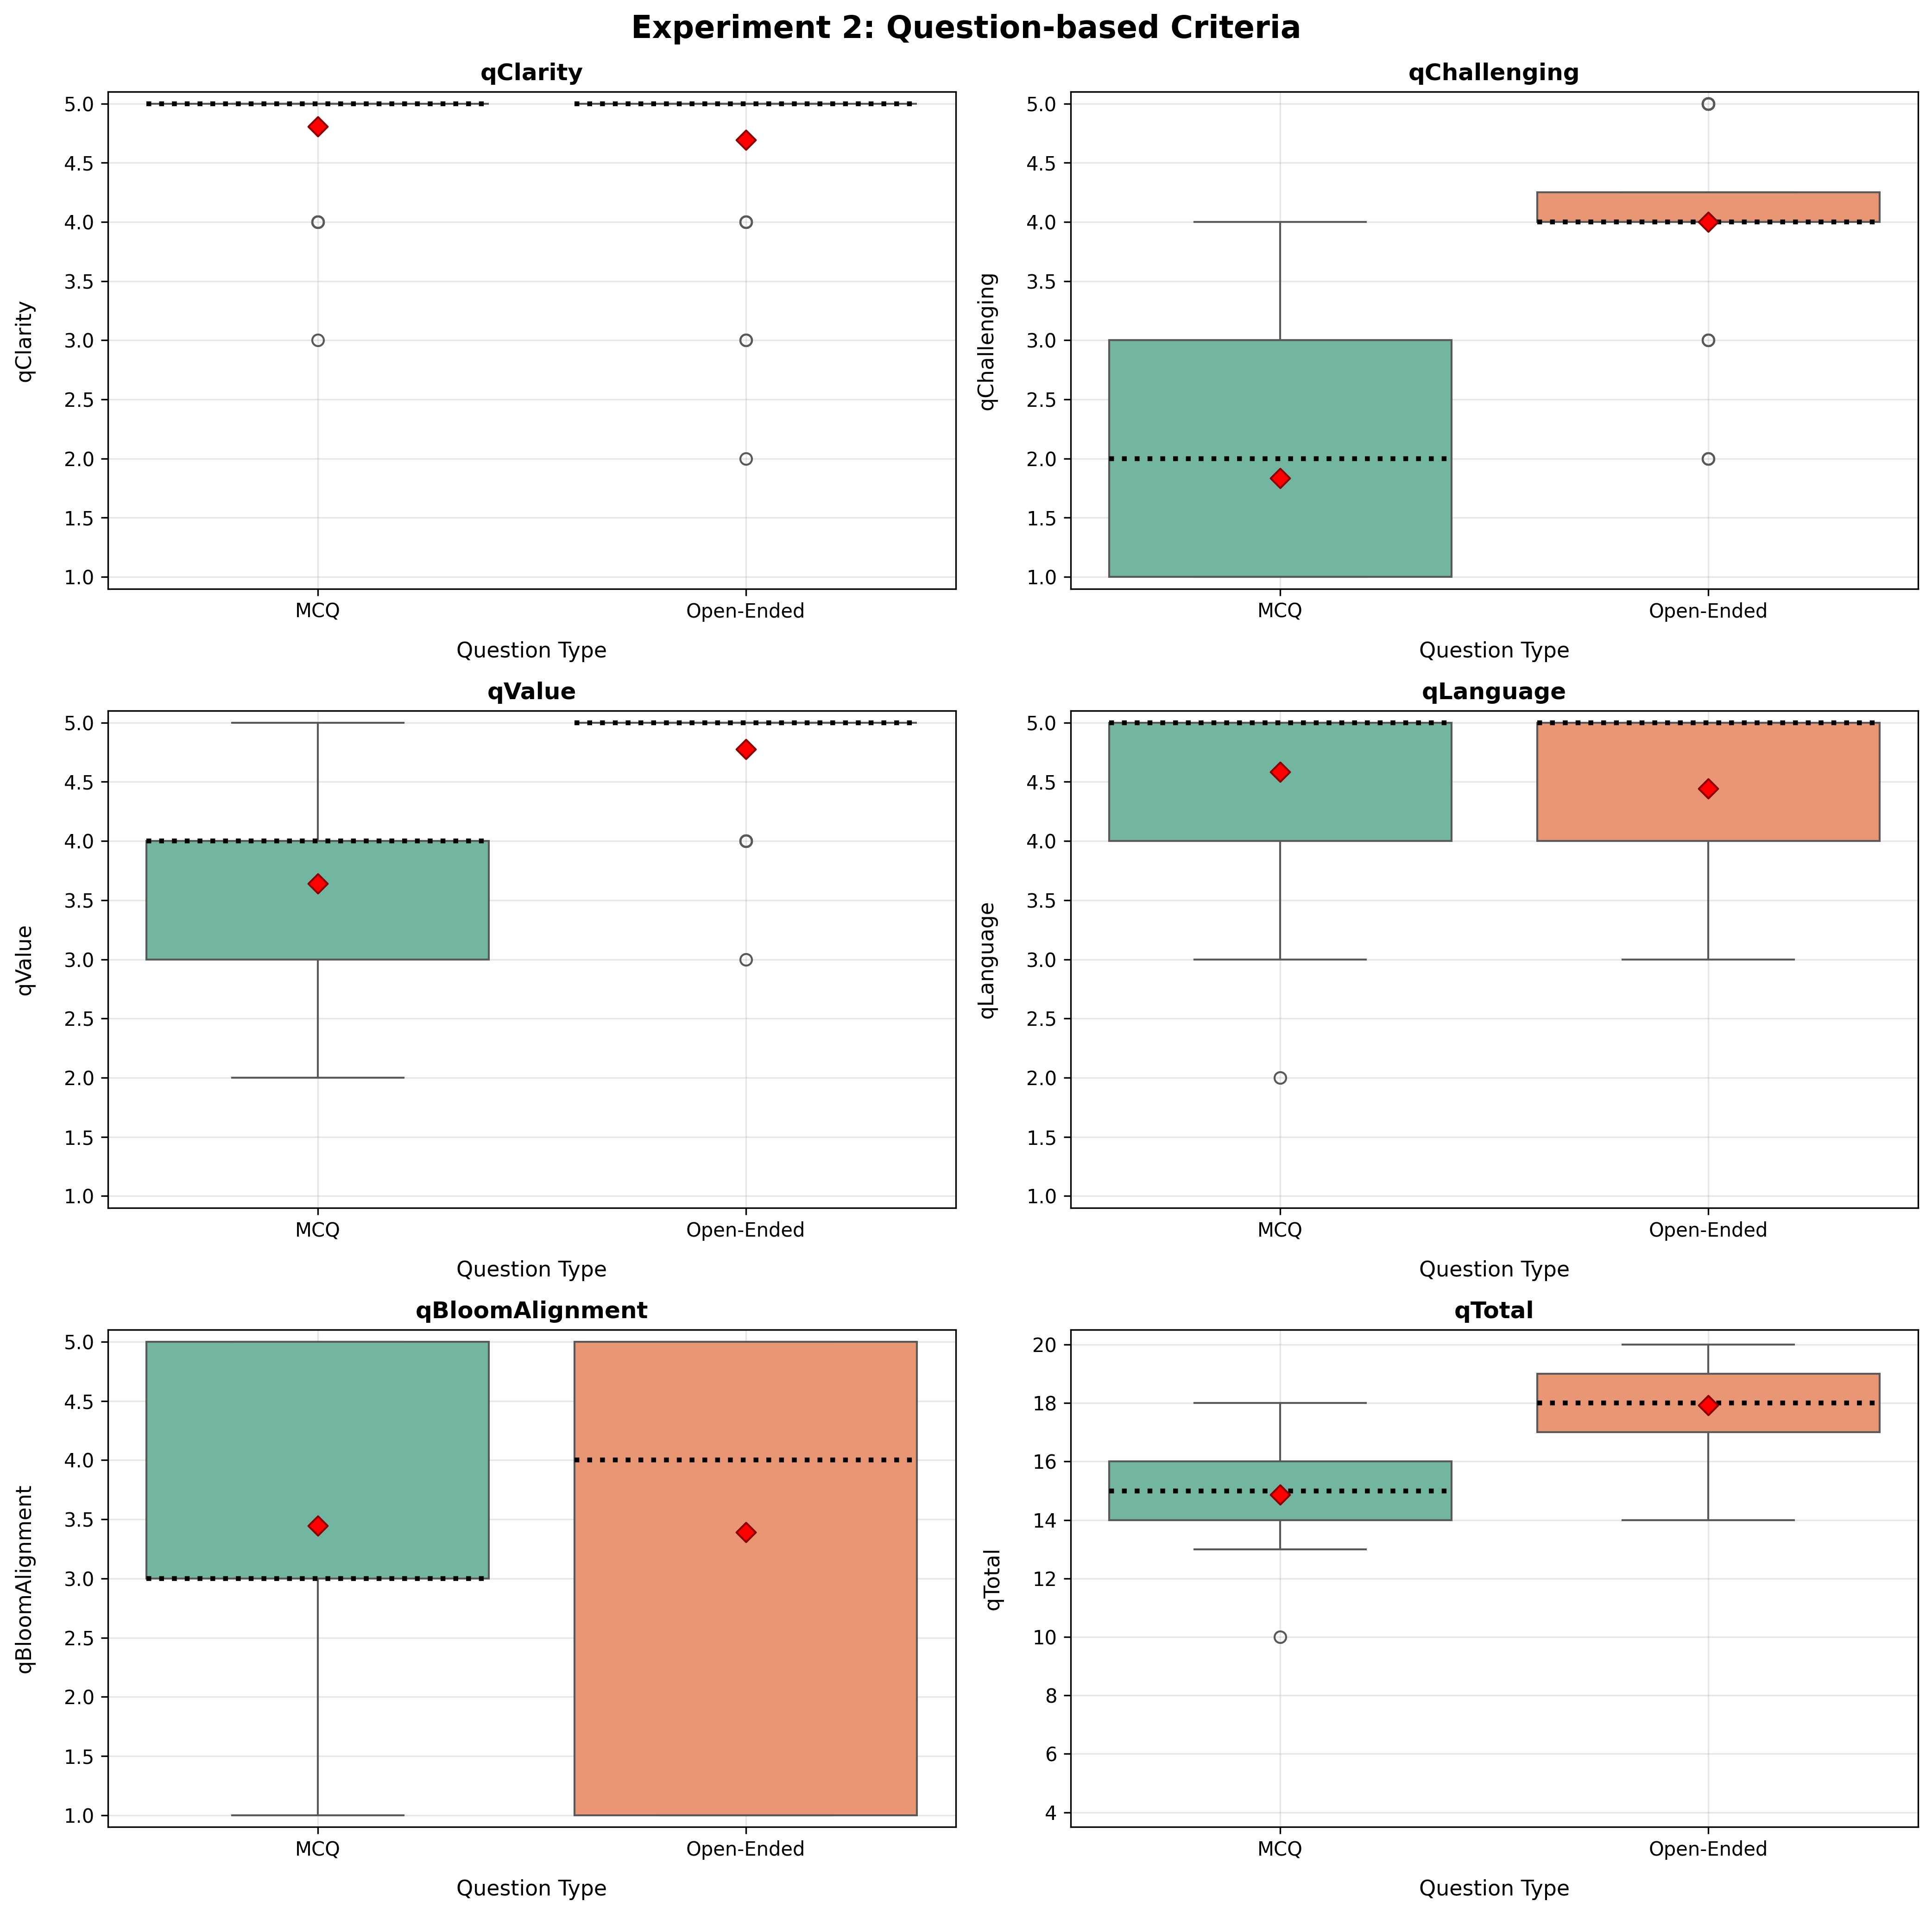

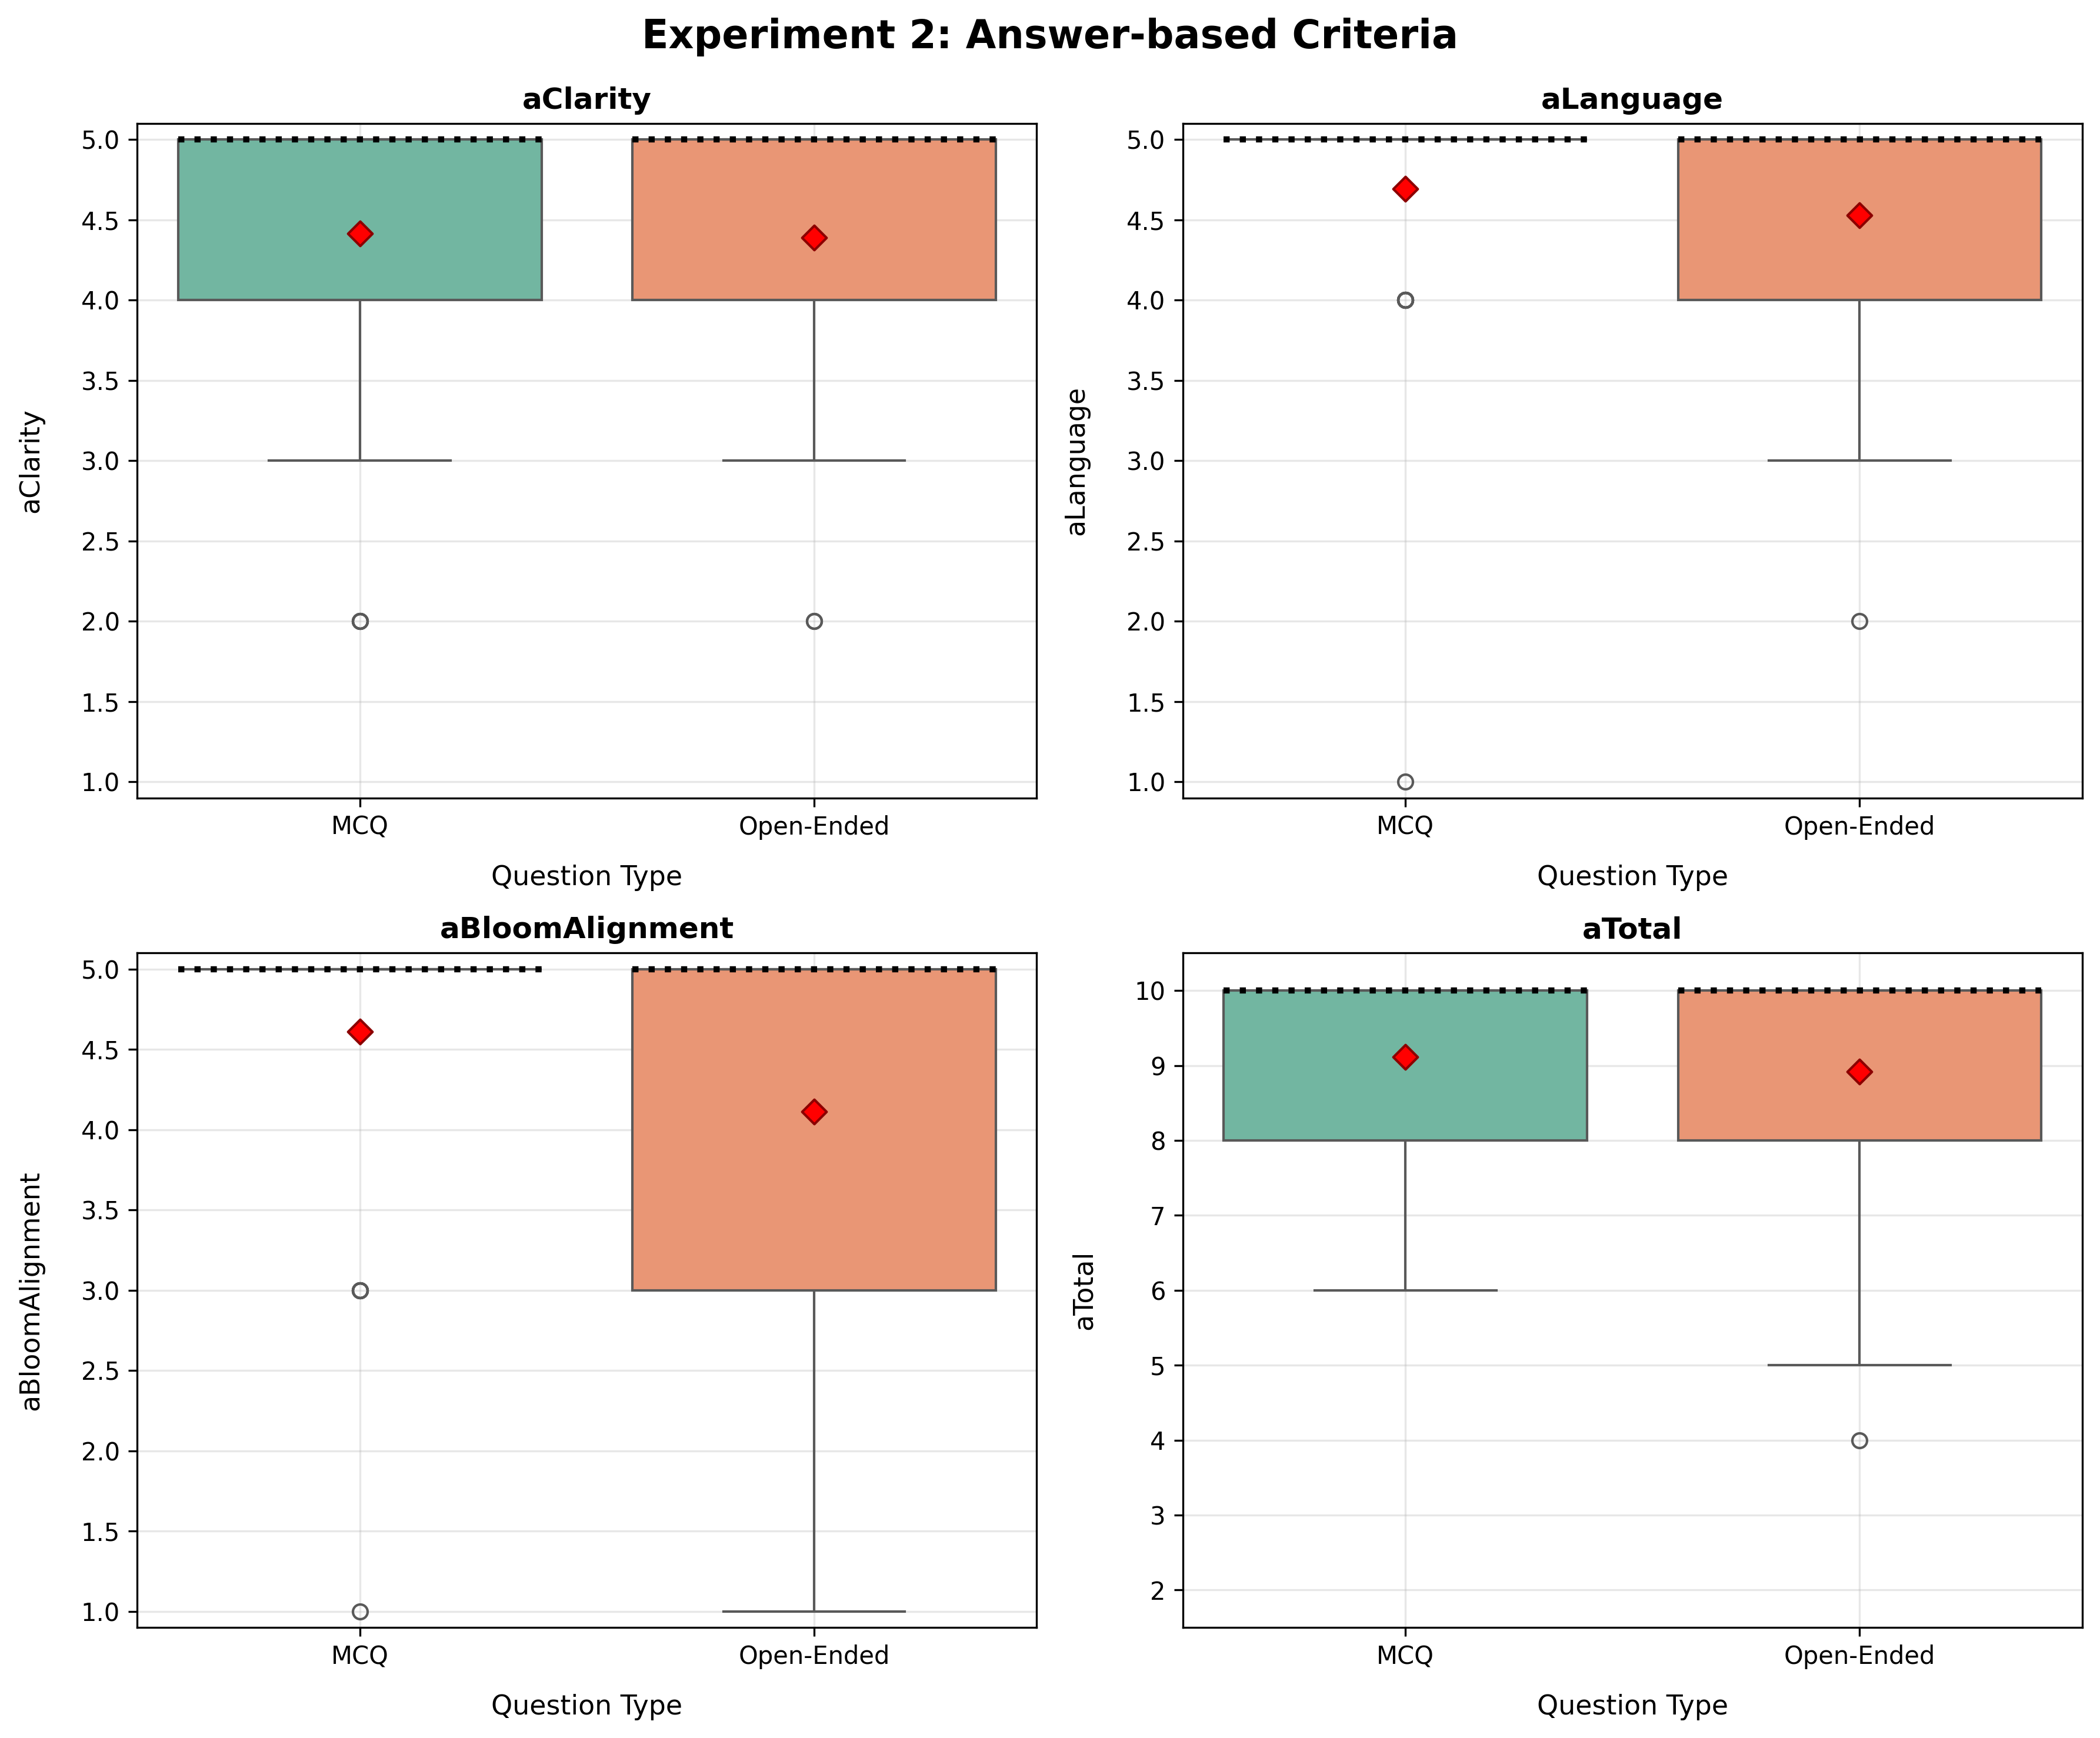

In [7]:
question_plot_metrics = EXP2_QUESTION_COLS + ['q_bloom_alignment', 'question_total_score']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
plots[f'exp2_question_bundle_question_type_{analysis_suffix}'] = fig

for i, criterion in enumerate(question_plot_metrics):
    scale_range = SCORE_RANGES.get(criterion, LIKERT_RANGE)
    create_seaborn_boxplot(
        exp2_df,
        'question_type',
        criterion,
        axes[i],
        DISPLAY_LABELS.get(criterion, criterion.title()),
        DISPLAY_LABELS.get(criterion, criterion.title()),
        'Question Type',
        scale_range=scale_range,
    )

plt.suptitle('Experiment 2: Question-based Criteria', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

answer_plot_metrics = EXP2_ANSWER_COLS + ['a_bloom_alignment', 'answer_total_score']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
plots[f'exp2_answer_bundle_question_type_{analysis_suffix}'] = fig

for i, criterion in enumerate(answer_plot_metrics):
    scale_range = SCORE_RANGES.get(criterion, LIKERT_RANGE)
    create_seaborn_boxplot(
        exp2_df,
        'question_type',
        criterion,
        axes[i],
        DISPLAY_LABELS.get(criterion, criterion.title()),
        DISPLAY_LABELS.get(criterion, criterion.title()),
        'Question Type',
        scale_range=scale_range,
    )

plt.suptitle('Experiment 2: Answer-based Criteria', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

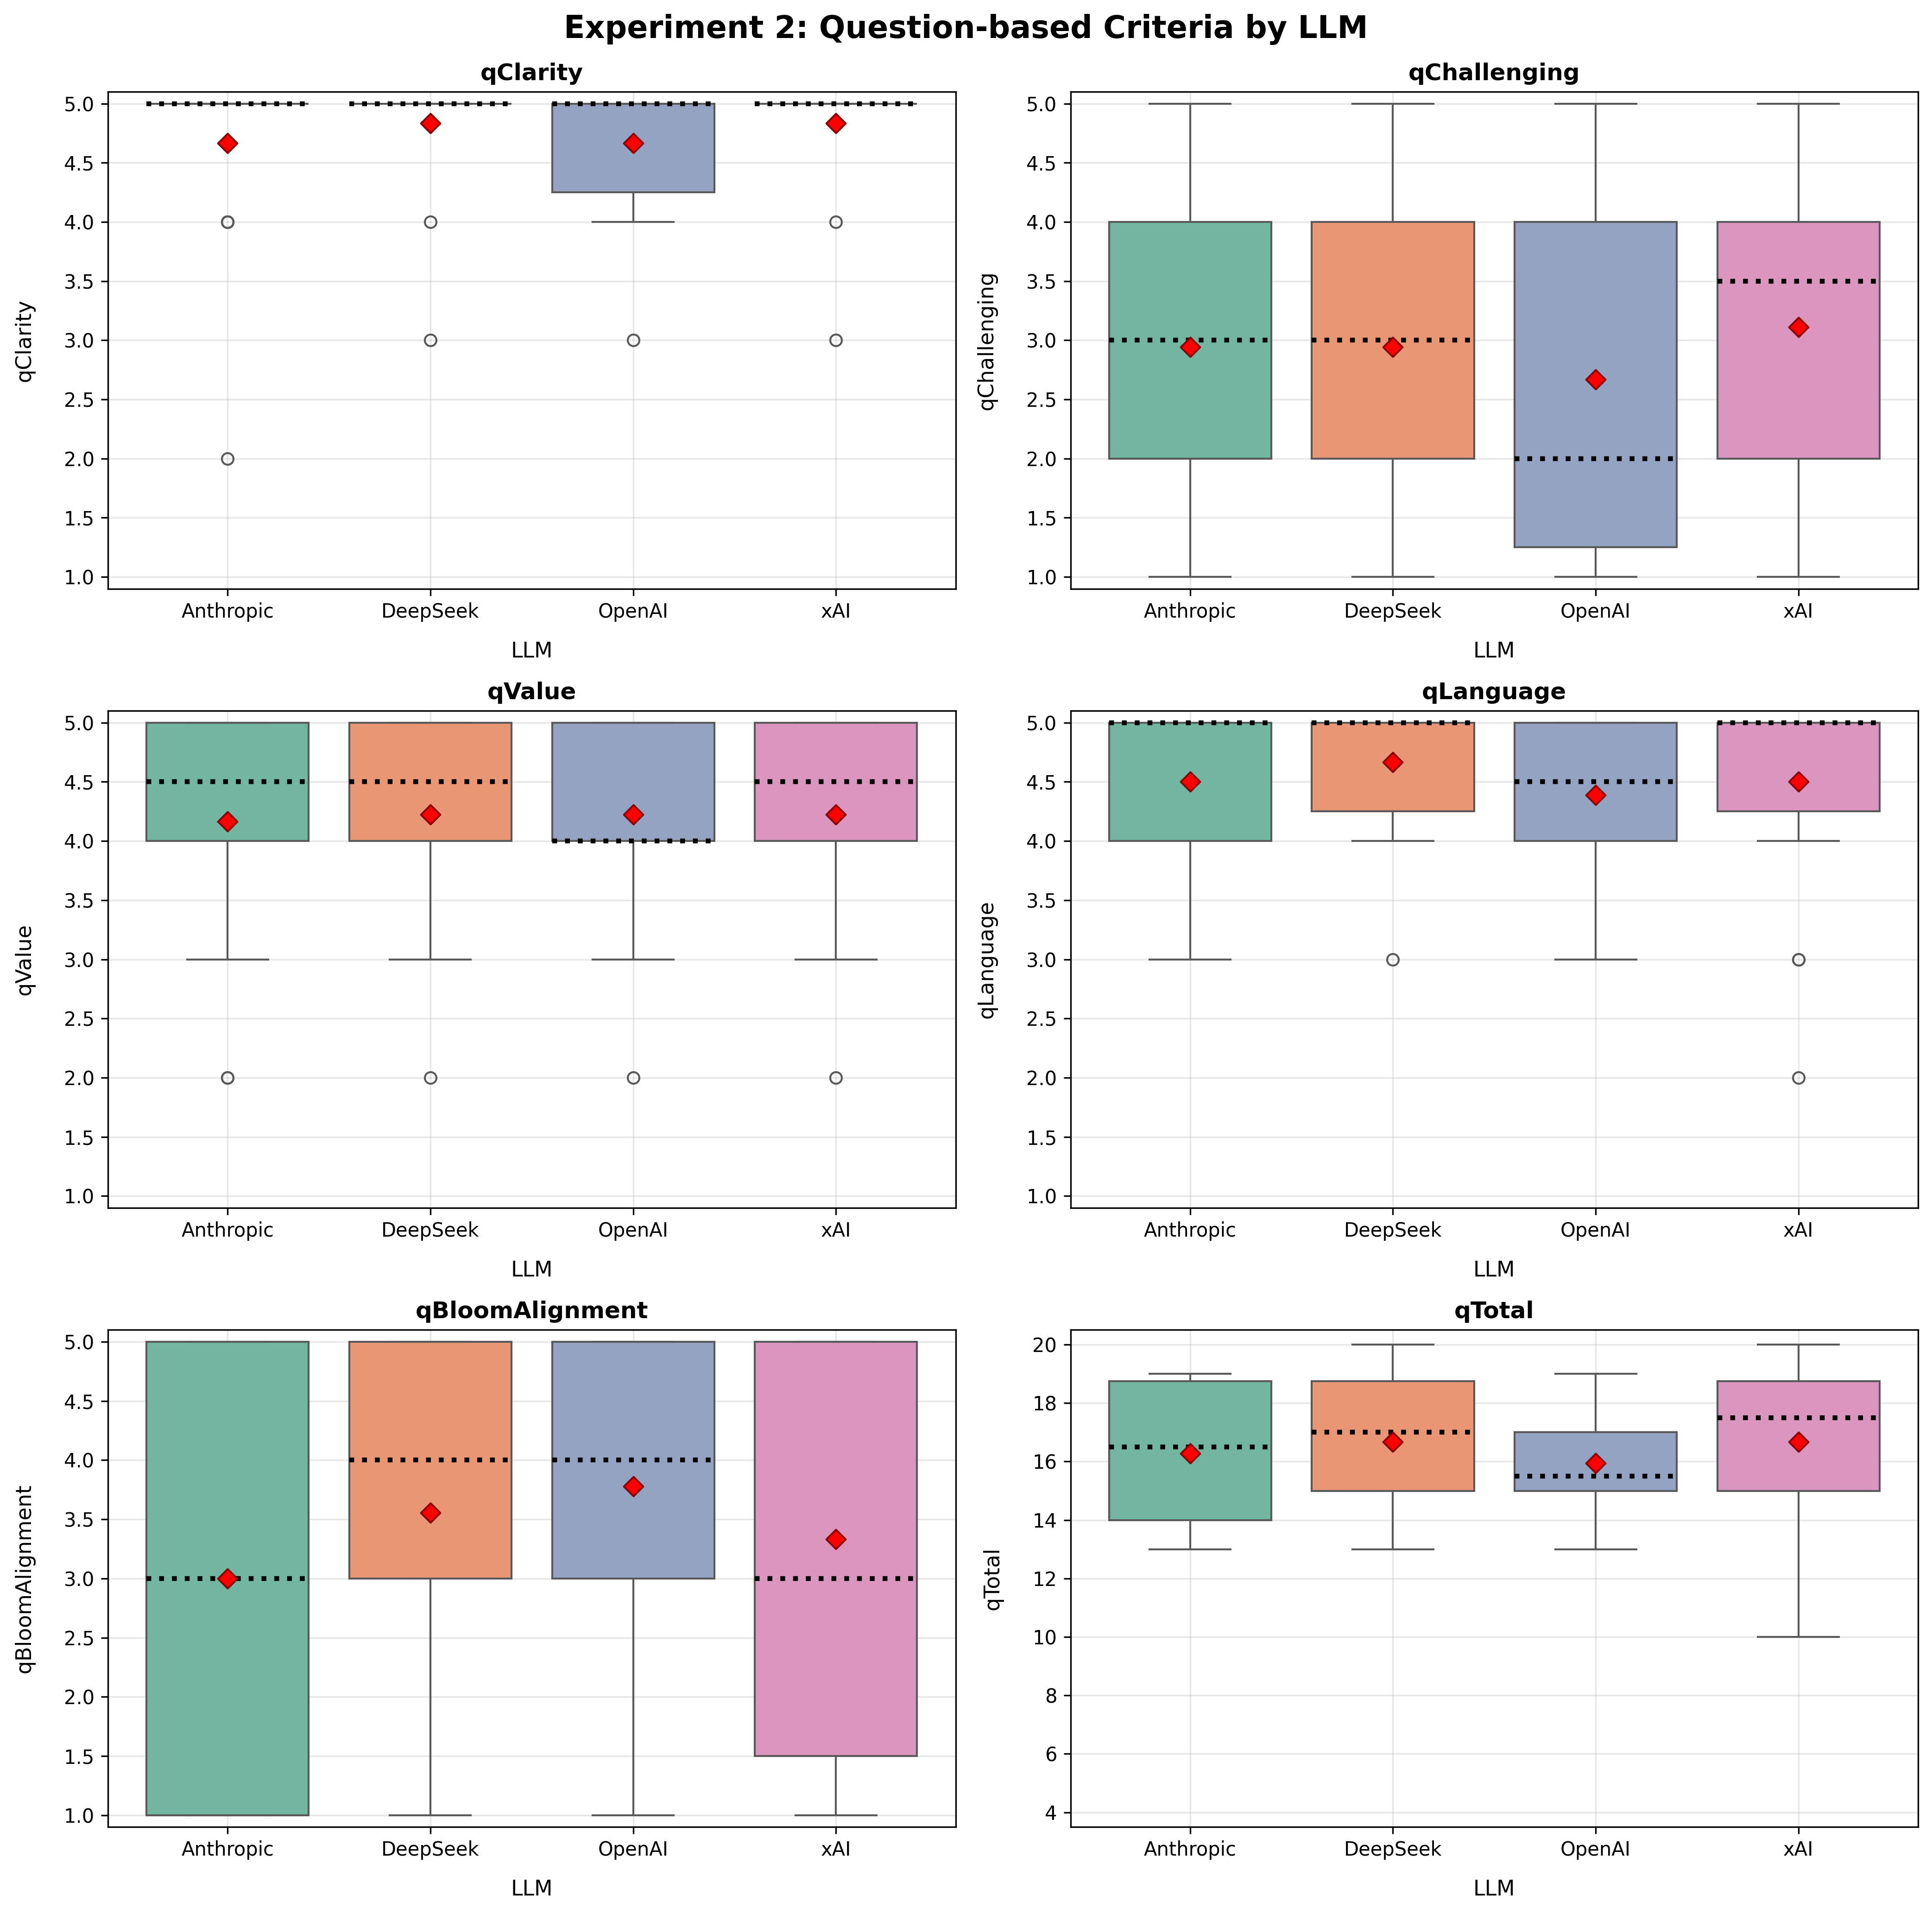

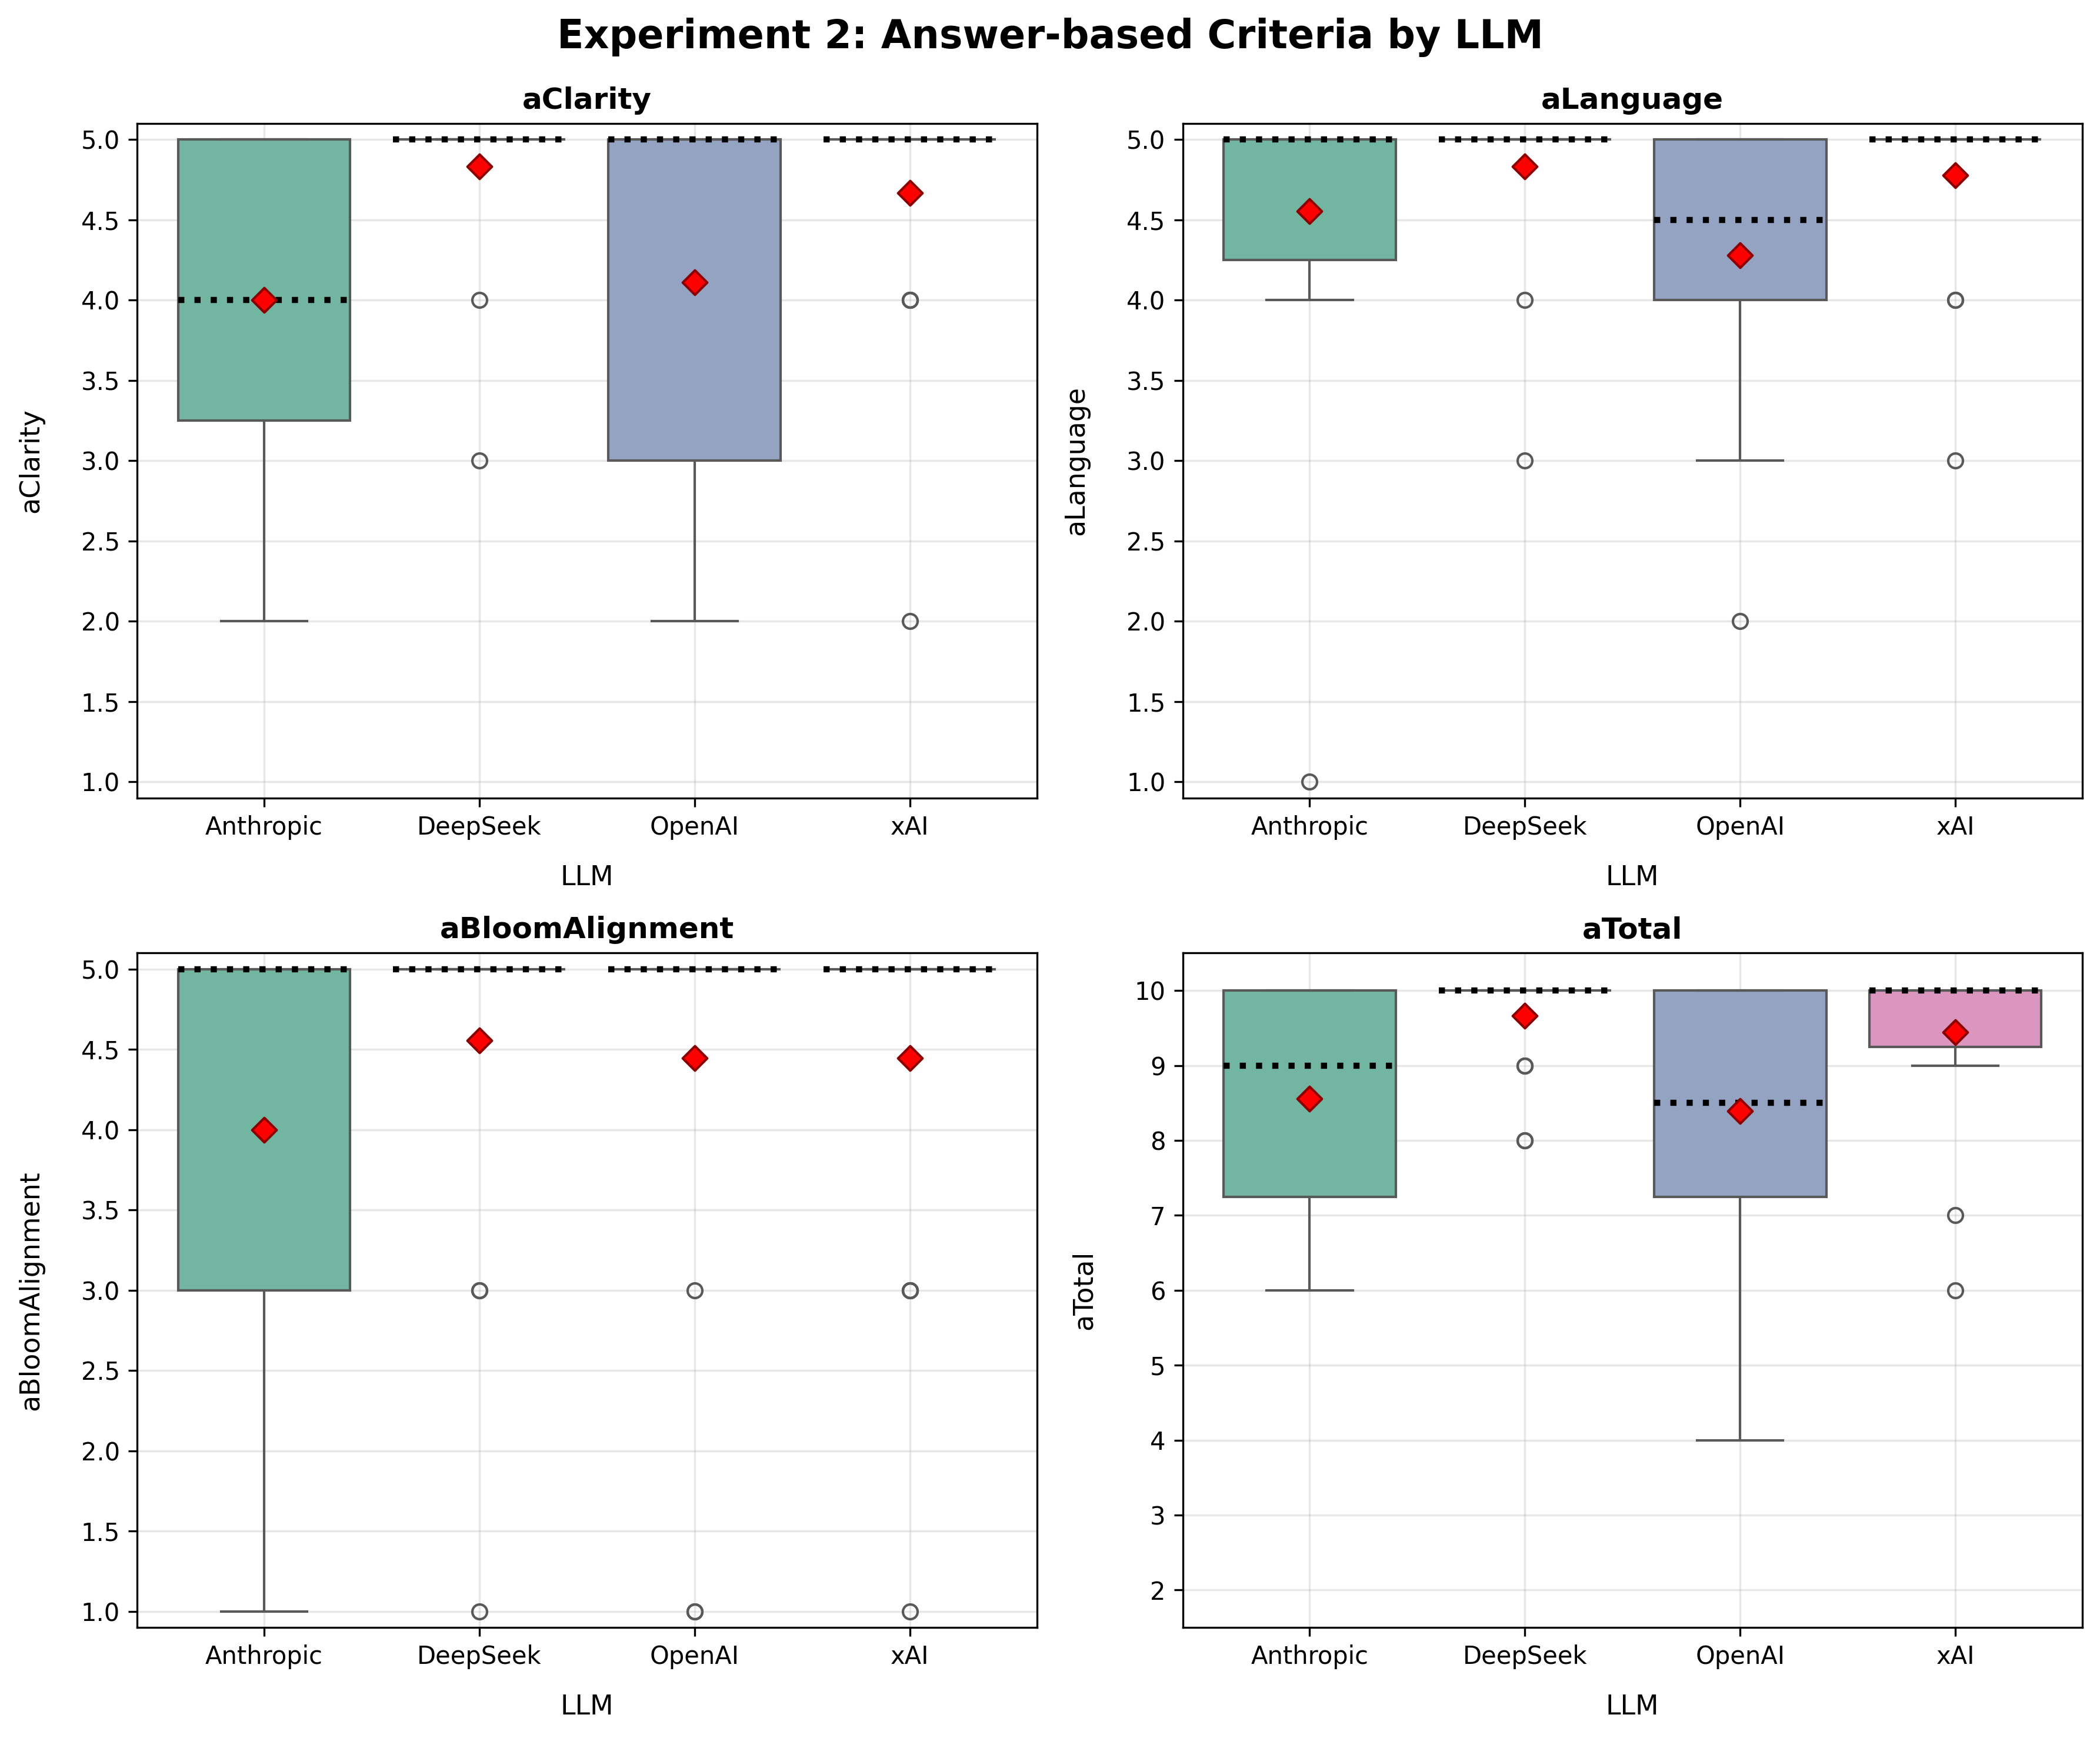

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
plots[f'exp2_question_bundle_llm_{analysis_suffix}'] = fig

for i, criterion in enumerate(question_plot_metrics):
    scale_range = SCORE_RANGES.get(criterion, LIKERT_RANGE)
    create_seaborn_boxplot(
        exp2_df,
        'llm',
        criterion,
        axes[i],
        DISPLAY_LABELS.get(criterion, criterion.title()),
        DISPLAY_LABELS.get(criterion, criterion.title()),
        'LLM',
        scale_range=scale_range,
    )

plt.suptitle('Experiment 2: Question-based Criteria by LLM', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
plots[f'exp2_answer_bundle_llm_{analysis_suffix}'] = fig

for i, criterion in enumerate(answer_plot_metrics):
    scale_range = SCORE_RANGES.get(criterion, LIKERT_RANGE)
    create_seaborn_boxplot(
        exp2_df,
        'llm',
        criterion,
        axes[i],
        DISPLAY_LABELS.get(criterion, criterion.title()),
        DISPLAY_LABELS.get(criterion, criterion.title()),
        'LLM',
        scale_range=scale_range,
    )

plt.suptitle('Experiment 2: Answer-based Criteria by LLM', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

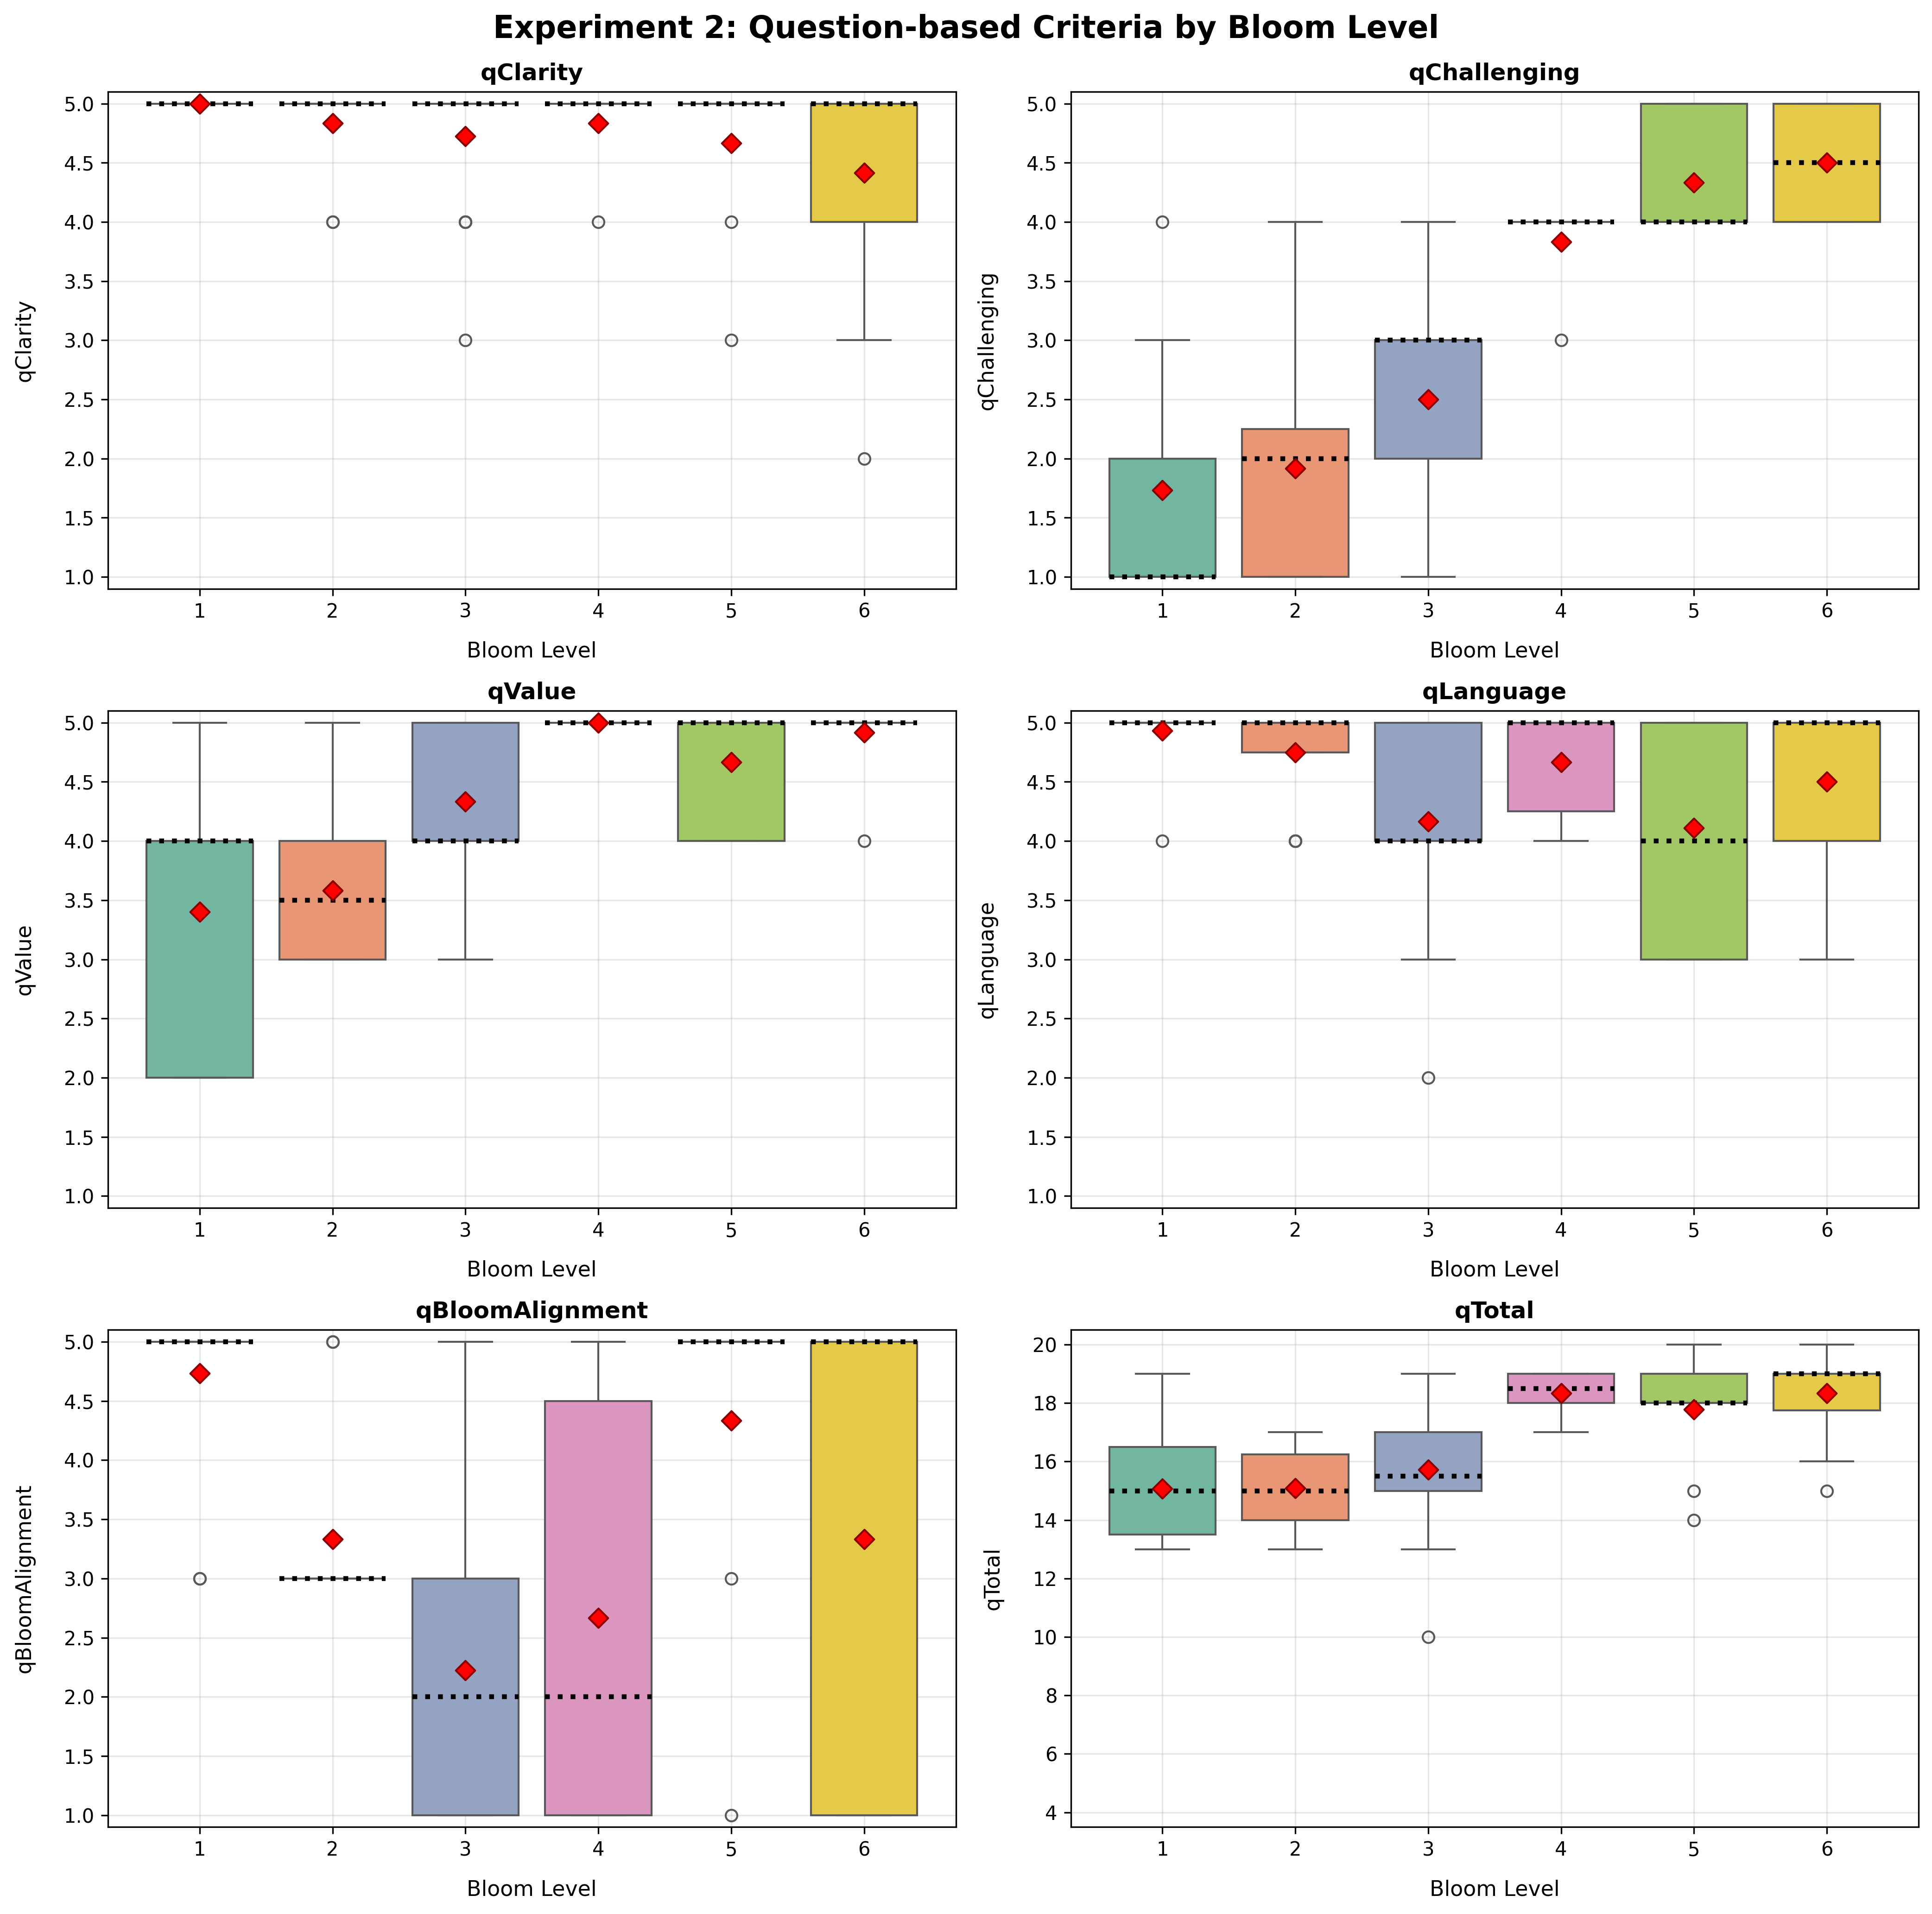

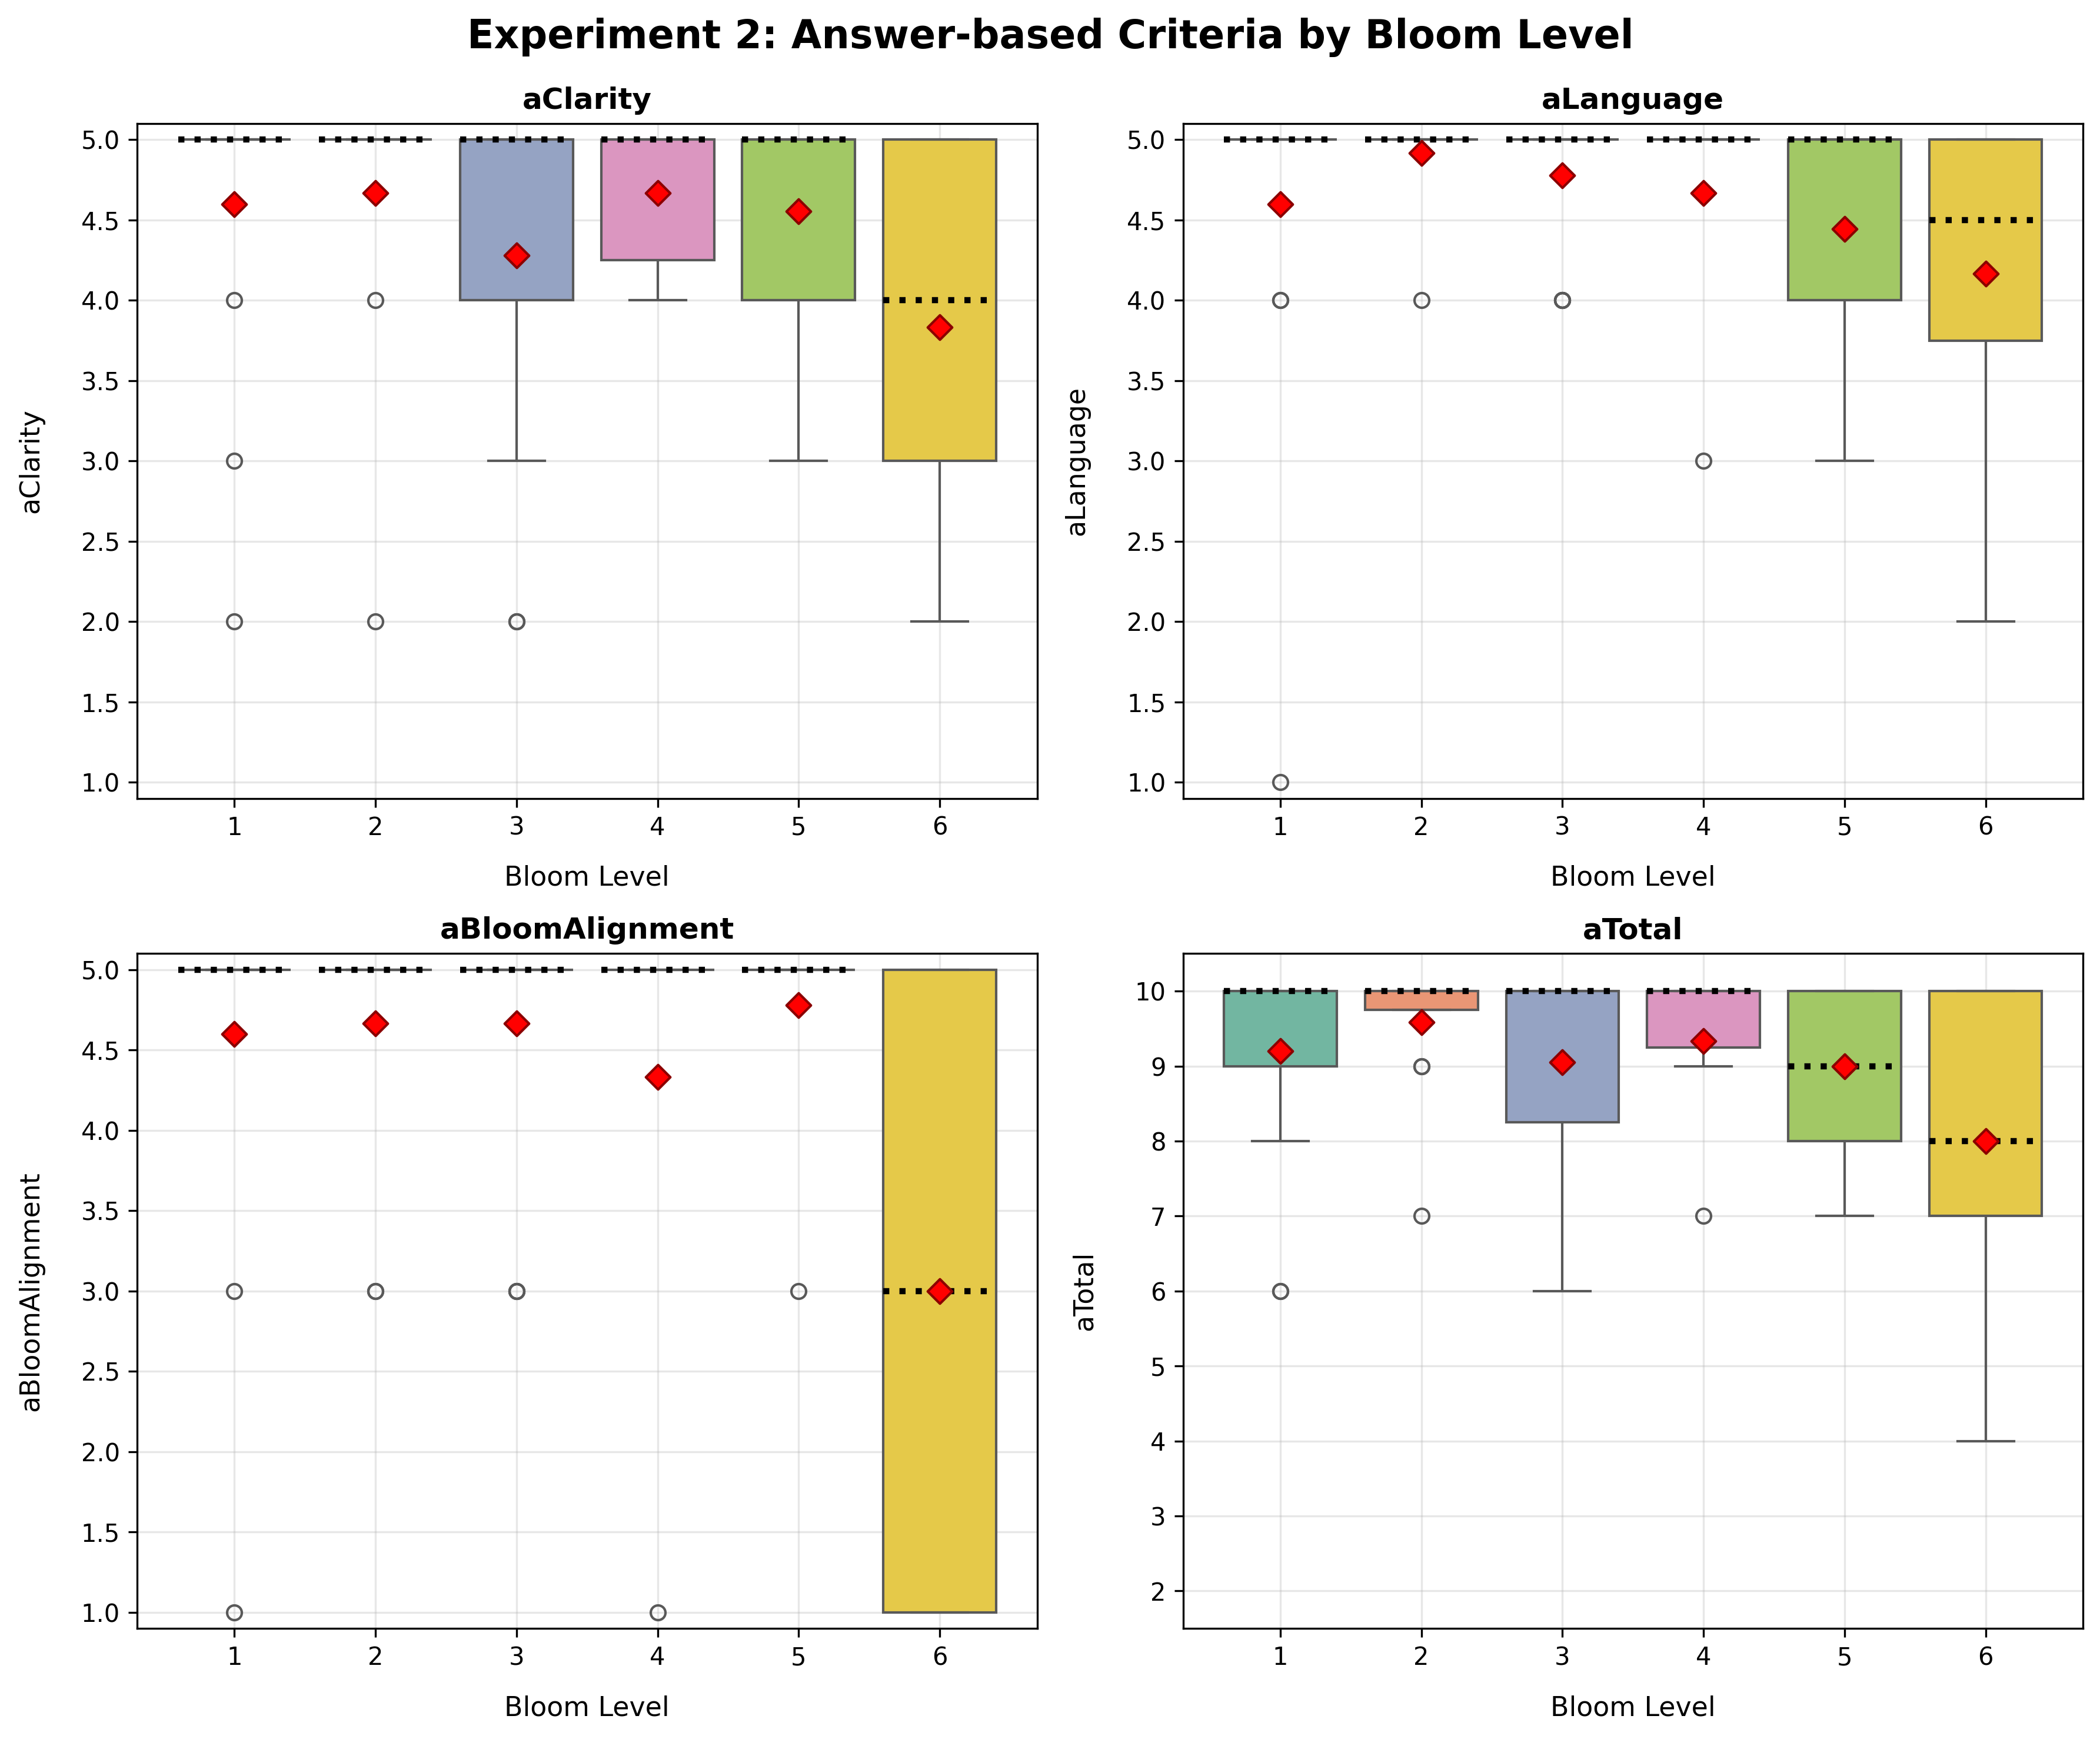

In [9]:
exp2_df_plot = exp2_df.copy()
exp2_df_plot['bloom_idx'] = pd.to_numeric(exp2_df_plot['bloom_idx'], errors='coerce')
exp2_df_plot = exp2_df_plot[exp2_df_plot['bloom_idx'].between(1, 6, inclusive='both')].copy()
LABEL_MAPPING.update({str(i): f'{i}' for i in range(1, 7)})

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
plots[f'exp2_question_bundle_bloom_{analysis_suffix}'] = fig

for i, criterion in enumerate(question_plot_metrics):
    scale_range = SCORE_RANGES.get(criterion, LIKERT_RANGE)
    create_seaborn_boxplot(
        exp2_df_plot,
        'bloom_idx',
        criterion,
        axes[i],
        DISPLAY_LABELS.get(criterion, criterion.title()),
        DISPLAY_LABELS.get(criterion, criterion.title()),
        'Bloom Level',
        scale_range=scale_range,
    )

plt.suptitle('Experiment 2: Question-based Criteria by Bloom Level', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
plots[f'exp2_answer_bundle_bloom_{analysis_suffix}'] = fig

for i, criterion in enumerate(answer_plot_metrics):
    scale_range = SCORE_RANGES.get(criterion, LIKERT_RANGE)
    create_seaborn_boxplot(
        exp2_df_plot,
        'bloom_idx',
        criterion,
        axes[i],
        DISPLAY_LABELS.get(criterion, criterion.title()),
        DISPLAY_LABELS.get(criterion, criterion.title()),
        'Bloom Level',
        scale_range=scale_range,
    )

plt.suptitle('Experiment 2: Answer-based Criteria by Bloom Level', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

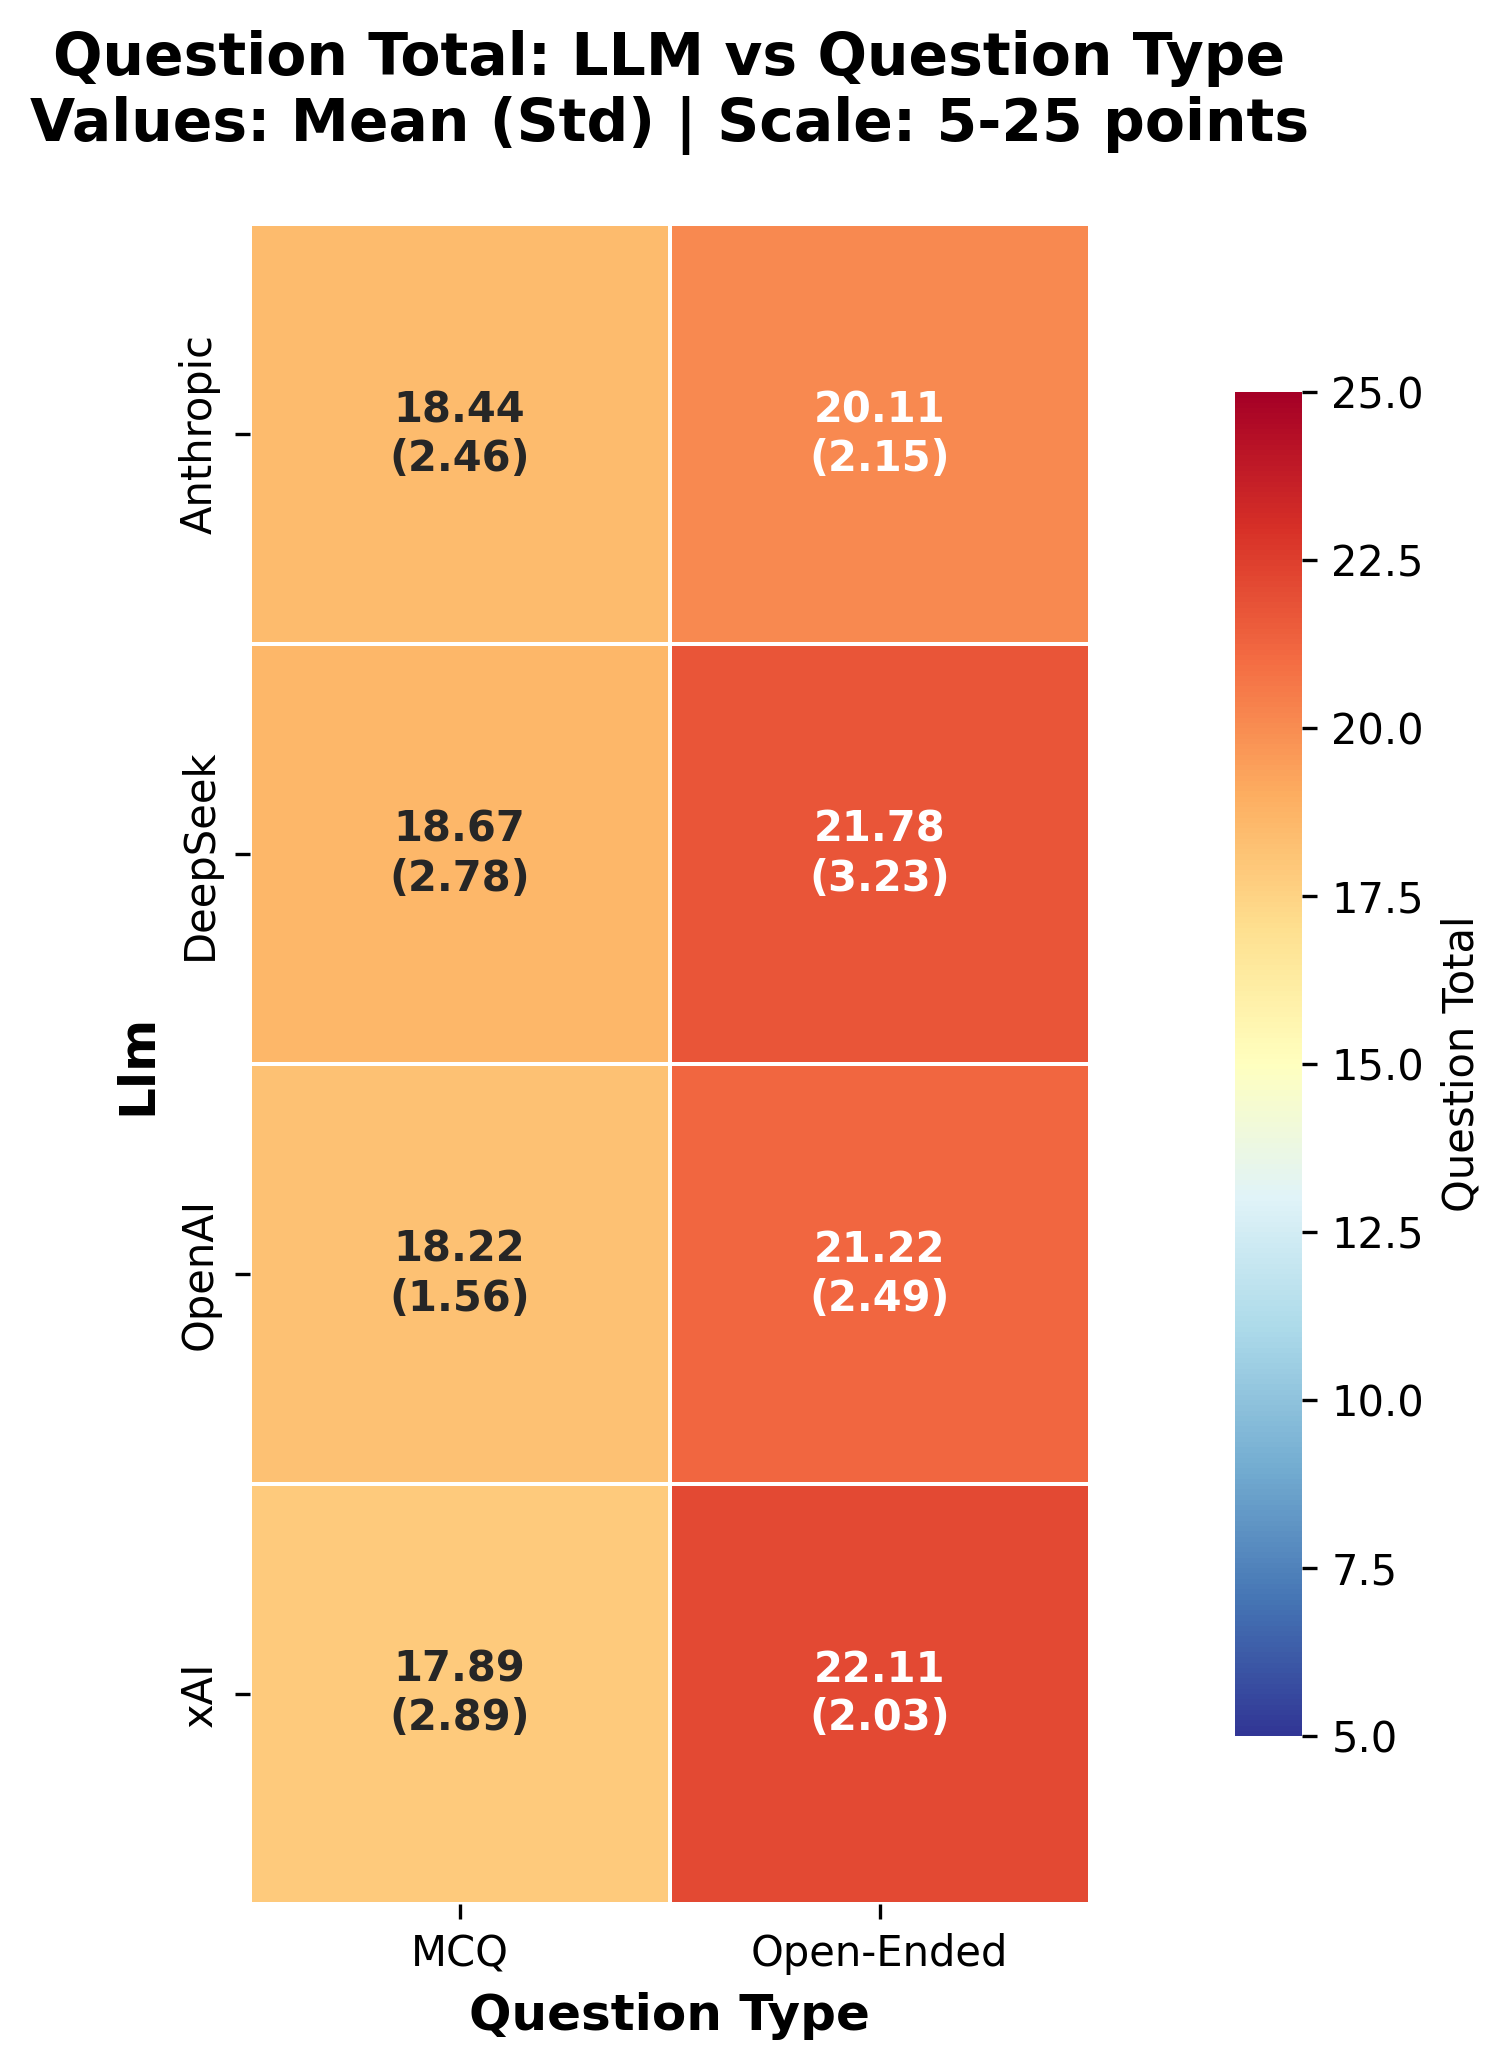

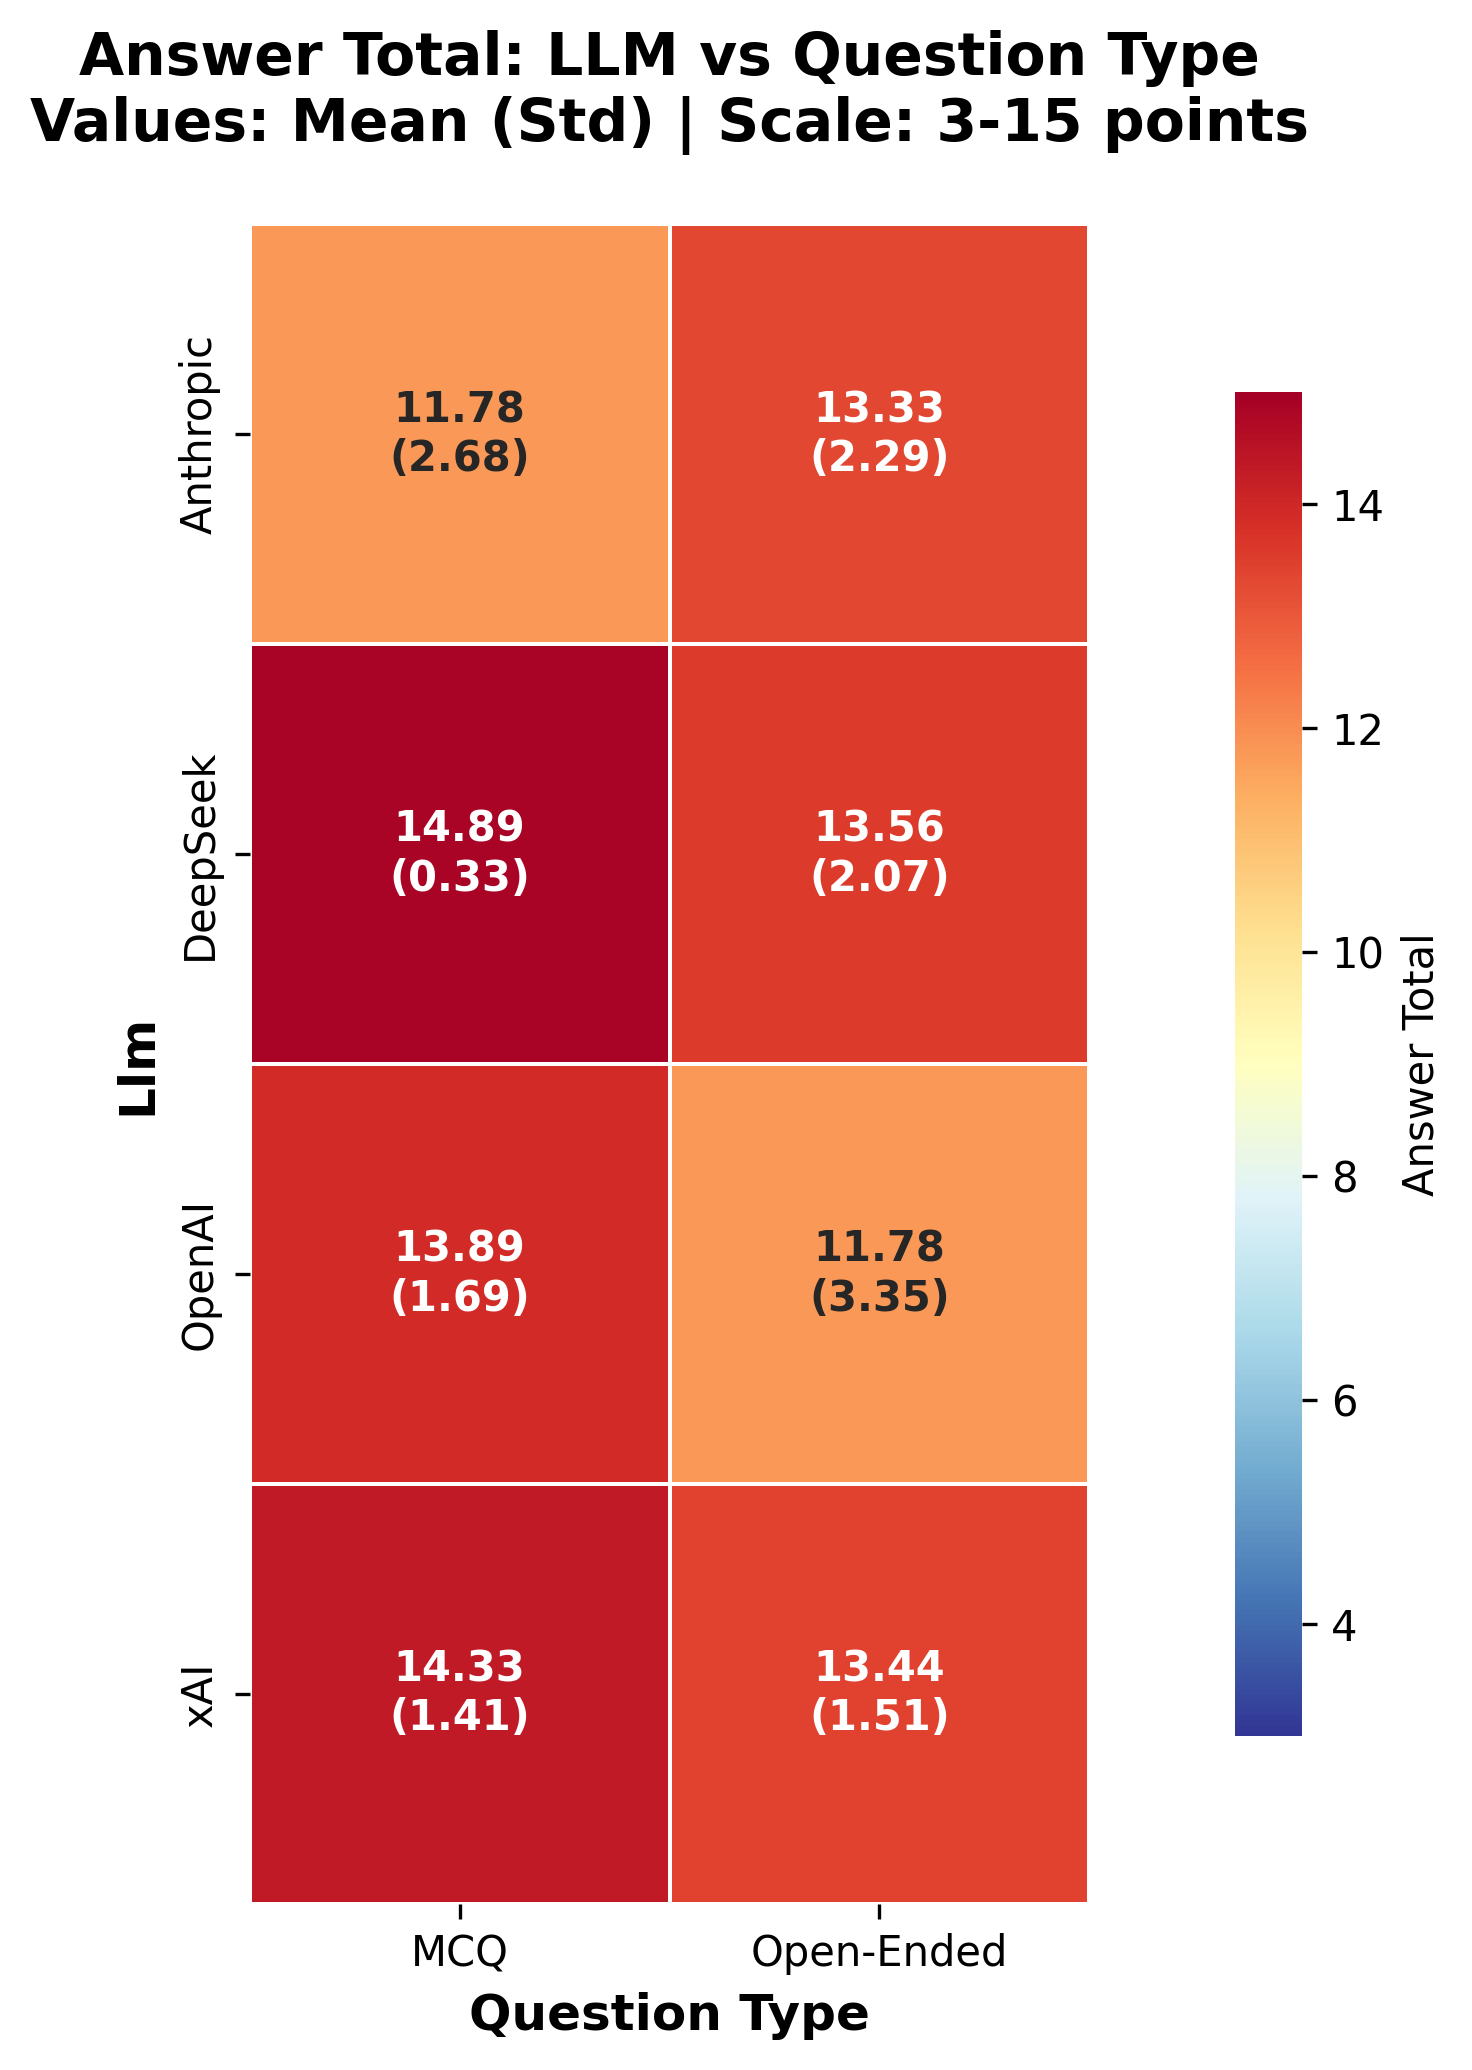

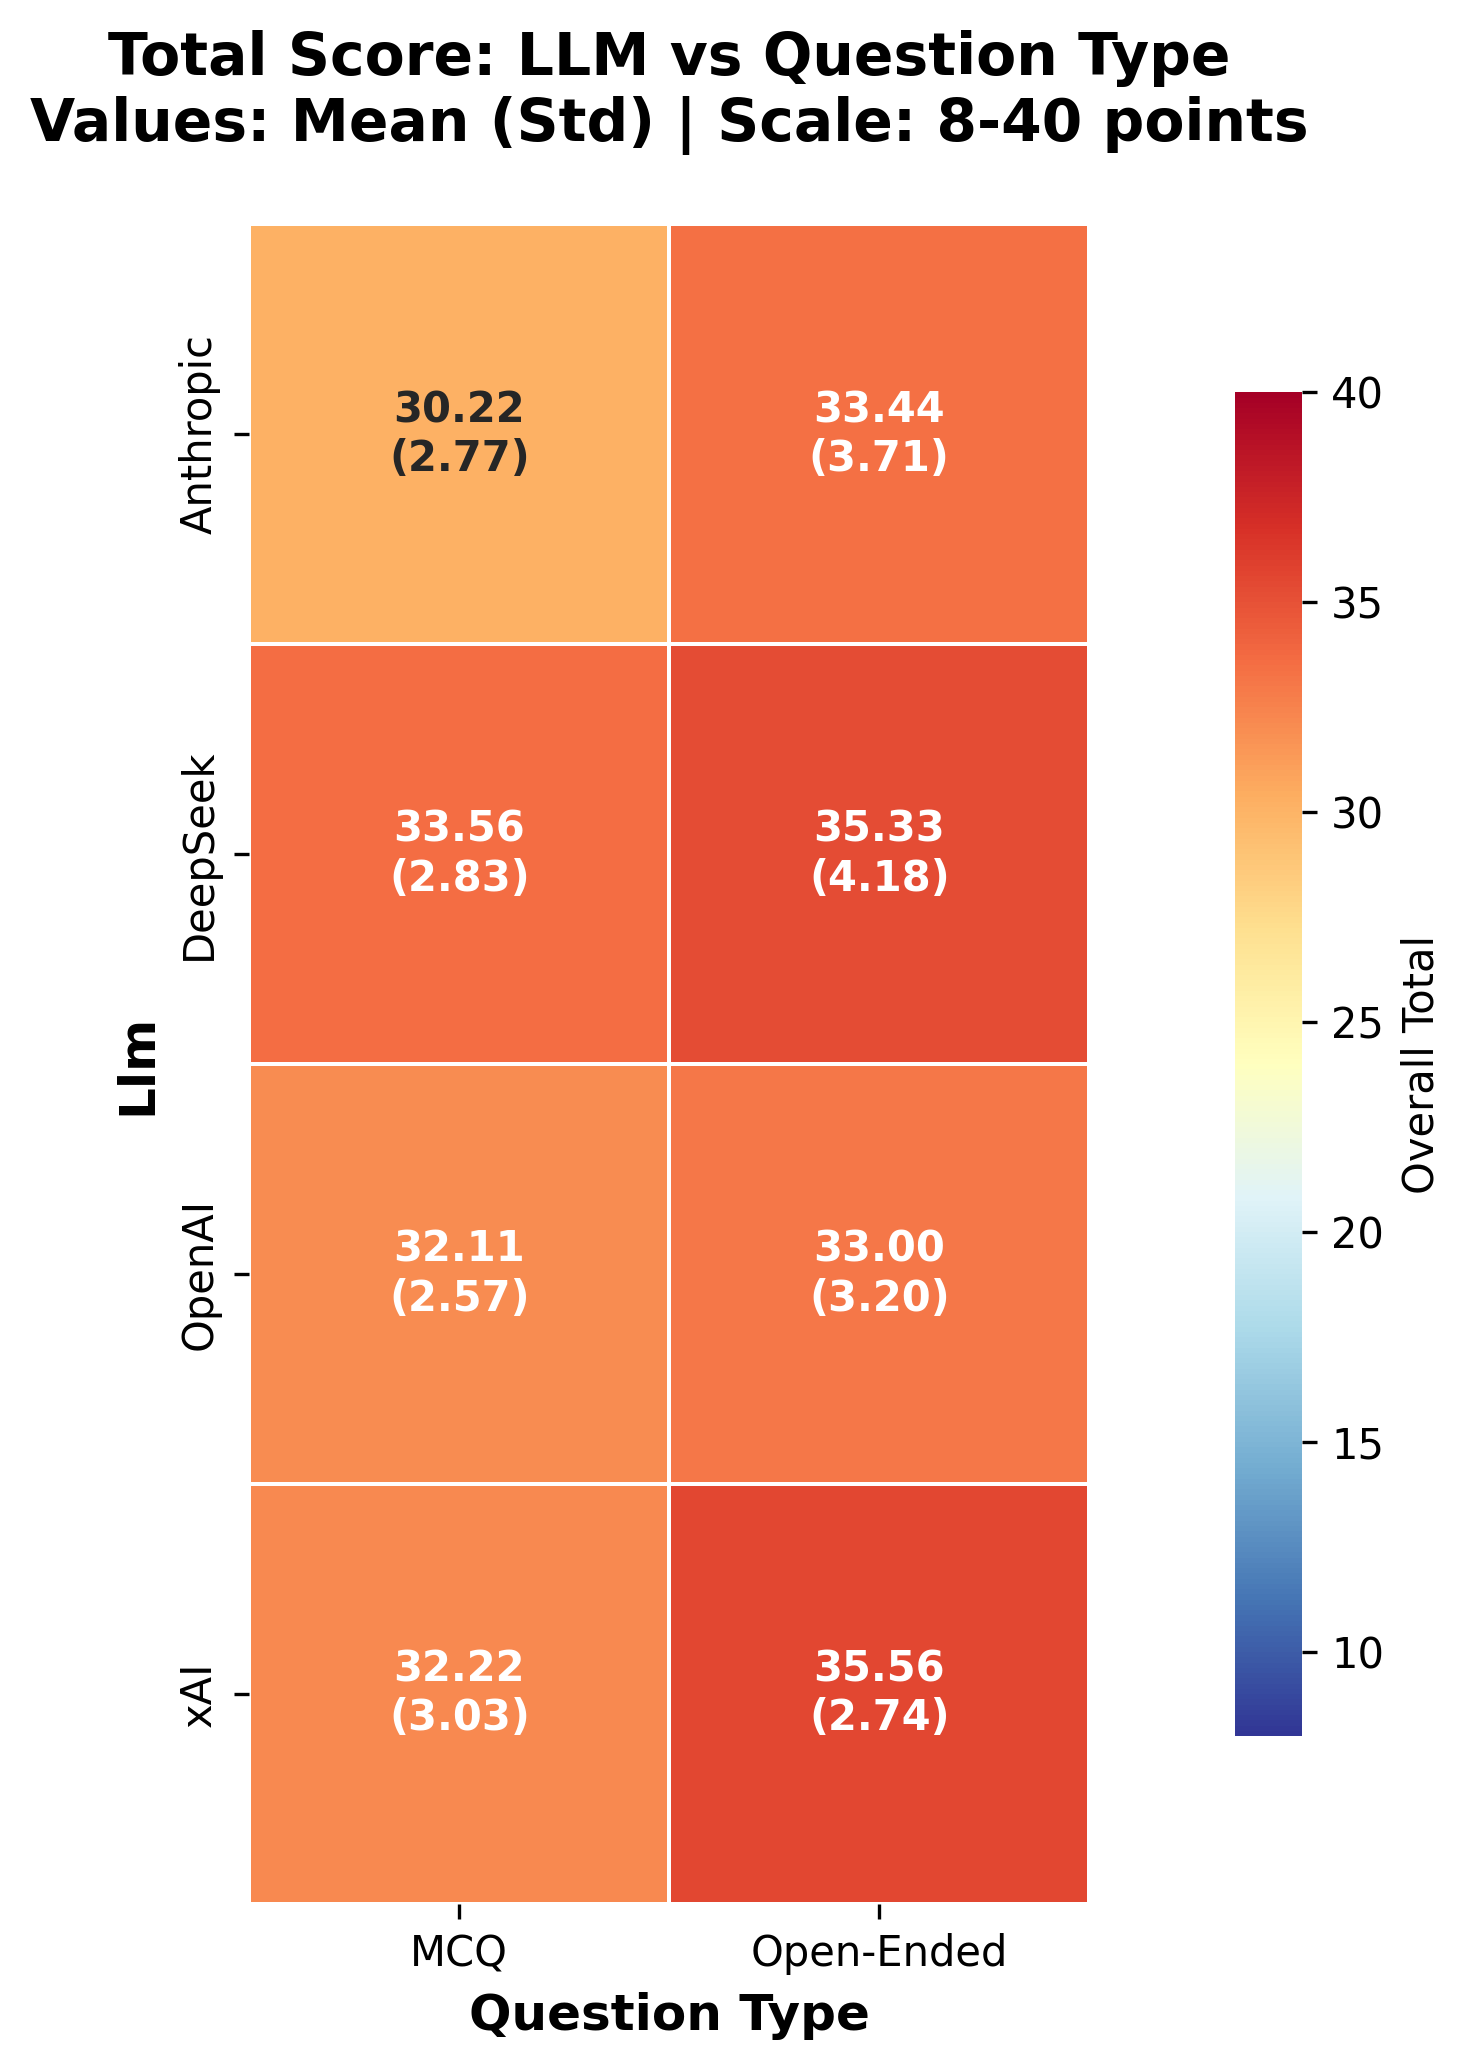

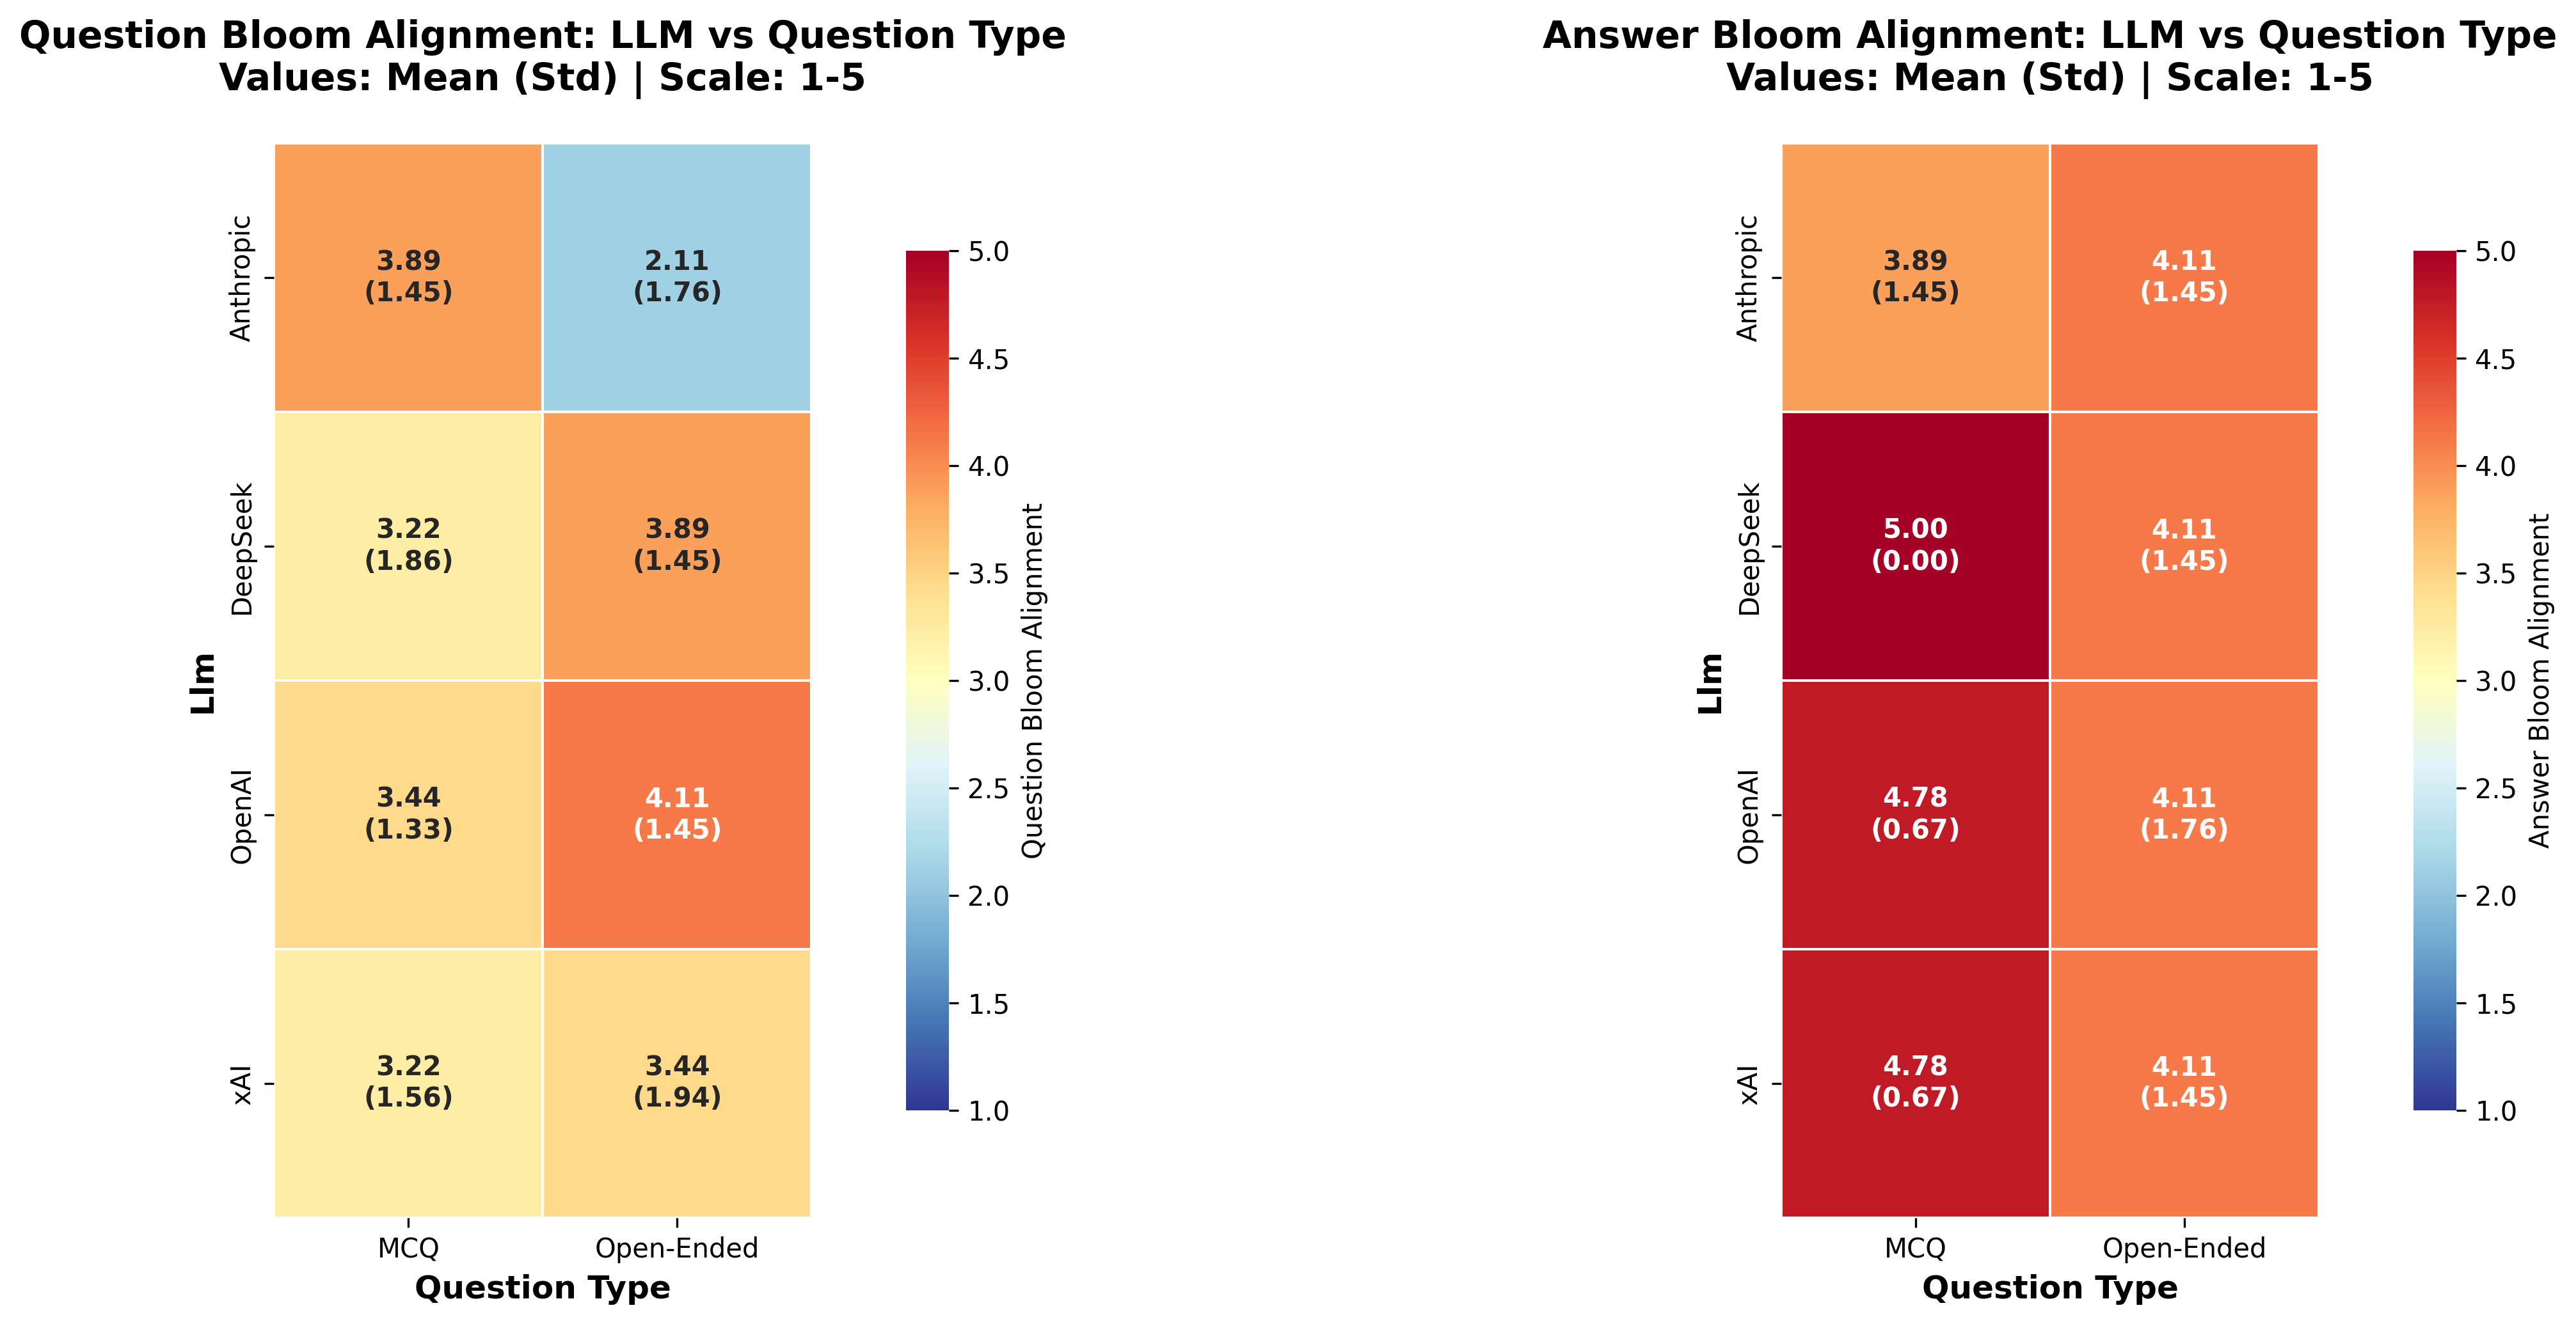

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
plots[f'exp2_question_total_heatmap_{analysis_suffix}'] = fig
create_heatmap(
    exp2_df,
    'llm',
    'question_type',
    'question_total_with_alignment',
    ax,
    'Question Total: LLM vs Question Type\nValues: Mean (Std) | Scale: 5-25 points',
    'Question Total',
    scale_range=SCORE_RANGES['question_total_with_alignment'],
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
plots[f'exp2_answer_total_heatmap_{analysis_suffix}'] = fig
create_heatmap(
    exp2_df,
    'llm',
    'question_type',
    'answer_total_with_alignment',
    ax,
    'Answer Total: LLM vs Question Type\nValues: Mean (Std) | Scale: 3-15 points',
    'Answer Total',
    scale_range=SCORE_RANGES['answer_total_with_alignment'],
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
plots[f'exp2_total_score_heatmap_{analysis_suffix}'] = fig
create_heatmap(
    exp2_df,
    'llm',
    'question_type',
    'total_with_alignment',
    ax,
    'Total Score: LLM vs Question Type\nValues: Mean (Std) | Scale: 8-40 points',
    'Overall Total',
    scale_range=SCORE_RANGES['total_with_alignment'],
)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plots[f'exp2_bloom_alignment_heatmaps_{analysis_suffix}'] = fig
create_heatmap(
    exp2_df,
    'llm',
    'question_type',
    'q_bloom_alignment',
    axes[0],
    'Question Bloom Alignment: LLM vs Question Type\nValues: Mean (Std) | Scale: 1-5',
    'Question Bloom Alignment',
    scale_range=SCORE_RANGES['q_bloom_alignment'],
 )
create_heatmap(
    exp2_df,
    'llm',
    'question_type',
    'a_bloom_alignment',
    axes[1],
    'Answer Bloom Alignment: LLM vs Question Type\nValues: Mean (Std) | Scale: 1-5',
    'Answer Bloom Alignment',
    scale_range=SCORE_RANGES['a_bloom_alignment'],
 )
plt.tight_layout()
plt.show()

# Inter-Rater Agreement Analysis

Agreement is computed across the unified set of available experts. Core question/answer criteria and Bloom alignment scores are analyzed on the 1-5 scale.

In [11]:
print("INTER-RATER AGREEMENT ANALYSIS (Fleiss' Kappa)")
print('=' * 60)
print(f'Analyzing agreement across {len(EXPERT_IDS)} experts: {EXPERT_IDS}')

expert_dfs_dict = {}
for expert_num in EXPERT_IDS:
    expert_key = f'expert_{expert_num}'
    if expert_key not in experts_data:
        continue
    expert_df = experts_data[expert_key].copy()
    expert_df = clean_numeric_data(expert_df, EXP2_QUESTION_COLS + EXP2_ANSWER_COLS, LIKERT_MIN, LIKERT_MAX)
    expert_df = clean_numeric_data(expert_df, EXP2_BLOOM_COLS, BLOOM_MIN, BLOOM_MAX, use_semicolon_max=True)
    expert_df = calculate_exp2_scores(expert_df)
    expert_dfs_dict[expert_key] = expert_df

agreement_non_bloom = calculate_fleiss_kappa_for_columns(
    expert_dfs_dict,
    EXP2_QUESTION_COLS + EXP2_ANSWER_COLS,
    LIKERT_MIN,
    LIKERT_MAX,
 )
agreement_bloom = calculate_fleiss_kappa_for_columns(
    expert_dfs_dict,
    ['q_bloom_rating', 'a_bloom_rating'],
    BLOOM_MIN,
    BLOOM_MAX,
)

agreement_exp2 = pd.concat([agreement_non_bloom, agreement_bloom], ignore_index=True)
agreement_exp2 = agreement_exp2.sort_values(
    'Criterion',
    key=lambda s: s.str.startswith('a_').astype(int),
    kind='stable'
).reset_index(drop=True)

if not agreement_exp2.empty:
    tables[f'agreement_exp2_{analysis_suffix}'] = agreement_exp2
    display(agreement_exp2.round(3))

    valid_kappas = agreement_exp2['Fleiss_Kappa'].dropna()
    if len(valid_kappas) > 0:
        avg_kappa = valid_kappas.mean()
        level = (
            'Poor' if avg_kappa < 0 else
            'Slight' if avg_kappa < 0.2 else
            'Fair' if avg_kappa < 0.4 else
            'Moderate' if avg_kappa < 0.6 else
            'Substantial' if avg_kappa < 0.8 else
            'Almost Perfect'
        )
        print(f"\nAverage Fleiss' Kappa: {avg_kappa:.3f} ({level})")

print('\n' + '=' * 60)
print('EXPERT COMPARISON - INDIVIDUAL STATISTICS')
print('=' * 60)

expert_means = {}
available_expert_keys = [k for k in [f'expert_{n}' for n in EXPERT_IDS] if k in experts_data]

for expert_key in available_expert_keys:
    cleaned_expert_df = clean_numeric_data(experts_data[expert_key], EXP2_QUESTION_COLS + EXP2_ANSWER_COLS, LIKERT_MIN, LIKERT_MAX)
    cleaned_expert_df = clean_numeric_data(cleaned_expert_df, EXP2_BLOOM_COLS, BLOOM_MIN, BLOOM_MAX, use_semicolon_max=True)
    cleaned_expert_df = calculate_exp2_scores(cleaned_expert_df)
    expert_means[expert_key] = cleaned_expert_df[EXP2_NUMERIC_COLS + EXP2_SCORE_COLS].mean()

comparison_df = pd.DataFrame(expert_means).T
comparison_df = comparison_df.round(3)
tables[f'expert_comparison_exp2_{analysis_suffix}'] = comparison_df

print('\nMean Ratings by Expert (Experiment 2):')
display(comparison_df)

if not agreement_exp2.empty:
    agreement_summary = agreement_exp2.groupby('Rating_Domain')[['Fleiss_Kappa', 'Mean_Rating', 'Std_Rating']].mean().round(3)
    tables[f'agreement_summary_exp2_{analysis_suffix}'] = agreement_summary
    print('Average agreement by rating group:')
    display(agreement_summary)
else:
    print('No agreement summary available.')

INTER-RATER AGREEMENT ANALYSIS (Fleiss' Kappa)
Analyzing agreement across 3 experts: [1, 2, 3]
Analyzing 3 experts with 24 common samples
Analyzing 3 experts with 24 common samples


,Criterion,Display_Label,Fleiss_Kappa,Agreement_Level,N_Items,N_Raters,Mean_Rating,Std_Rating,Scale,Rating_Domain
0,q_clarity,qClarity,0.107,Slight,24,3,4.75,0.60,1-5,Question
1,q_challenging,qChallenging,0.181,Slight,24,3,2.92,1.38,1-5,Question
2,q_value,qValue,0.183,Slight,24,3,4.21,0.93,1-5,Question
3,q_language,qLanguage,0.091,Slight,24,3,4.51,0.73,1-5,Question
4,q_bloom_rating,qBloomRating,0.437,Moderate,24,3,2.51,1.75,1-6,Question
5,a_clarity,aClarity,0.031,Slight,24,3,4.40,0.97,1-5,Answer
6,a_language,aLanguage,0.276,Fair,24,3,4.61,0.77,1-5,Answer
7,a_bloom_rating,aBloomRating,0.241,Fair,24,3,2.35,1.62,1-6,Answer



Average Fleiss' Kappa: 0.193 (Slight)

EXPERT COMPARISON - INDIVIDUAL STATISTICS

Mean Ratings by Expert (Experiment 2):


,q_clarity,q_challenging,q_value,q_language,a_clarity,a_language,q_bloom_alignment,a_bloom_alignment,bloom_alignment_total,question_total_score,answer_total_score,total_score
expert_1,4.542,3.292,4.083,4.417,4.167,4.708,3.333,4.167,7.500,16.333,8.875,25.208
expert_2,4.958,2.875,4.375,4.667,4.417,4.292,3.667,4.500,8.167,16.875,8.708,25.583
expert_3,4.750,2.583,4.167,4.458,4.625,4.833,3.250,4.417,7.667,15.958,9.458,25.417


Average agreement by rating group:


,Fleiss_Kappa,Mean_Rating,Std_Rating
Rating_Domain,,,
Answer,0.183,3.787,1.120
Question,0.200,3.780,1.078


## Data Export

Save all tables and plots for further analysis and reporting.

In [12]:
for table_name, table_df in tables.items():
    if isinstance(table_df, pd.DataFrame):
        safe_name = table_name.replace(' ', '_').replace('(', '').replace(')', '').replace("'", '').lower()
        csv_path = os.path.join(output_tables_path, f'{safe_name}.csv')
        table_df.to_csv(csv_path)
        print(f'Saved table: {csv_path}')

for plot_name, fig in plots.items():
    safe_name = plot_name.replace(' ', '_').replace('(', '').replace(')', '').replace("'", '').lower()
    png_path = os.path.join(output_plots_path, f'{safe_name}.png')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f'Saved plot: {png_path}')

print(f'\nAnalysis complete. Results saved to: {output_base_path}')

Saved table: /home/malde/git/question-generation/40_evaluation/exp2/qualitative/tables/exp2_overall_stats_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp2/qualitative/tables/exp2_llm_stats_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp2/qualitative/tables/exp2_llm_ranking_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp2/qualitative/tables/exp2_question_type_stats_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp2/qualitative/tables/agreement_exp2_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp2/qualitative/tables/expert_comparison_exp2_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp2/qualitative/tables/agreement_summary_exp2_experts.csv
Saved plot: /home/malde/git/question-generation/40_evaluation/exp2/qualitative/plots/exp2_question_bundle_question_type_experts.png
Saved plot: /home/malde/git/question-g